# Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import geopandas as gpd

from shapely.geometry import Polygon
from shapely.geometry import Point
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm
from sklearn import preprocessing
from sklearn.cluster import Birch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.special import rel_entr, kl_div
from scipy.stats import entropy
import math
import time
import random
import warnings
warnings.filterwarnings('ignore')

path_lta_data = '/content/drive/MyDrive/Colab Notebooks/data_fusion_fcl/lta_data/'
path_seoul_data = '/content/drive/MyDrive/Colab Notebooks/datasets/Seoul/'
path_od_data = '/content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_data_r1/'
path_od_result = '/content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_result_r1/'
path_od_figure = '/content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_figure/'


def reduce_mem_usage(props):
    start_mem_usg = props.memory_usage().sum() / 1024**2
    #print("Memory usage of properties dataframe is :",start_mem_usg," MB")
    NAlist = [] # Keeps track of columns that have missing values filled in.
    for col in props.columns:
        if (props[col].dtype != object) & (props[col].dtype != 'category'):  # Exclude strings

            # make variables for Int, max and min
            IsInt = False
            mx = props[col].max()
            mn = props[col].min()

            # Integer does not support NA, therefore, NA needs to be filled
            if not np.isfinite(props[col]).all():
                NAlist.append(col)
                props[col].fillna(mn-1,inplace=True)

            # test if column can be converted to an integer
            asint = props[col].fillna(0).astype(np.int64)
            result = (props[col] - asint)
            result = result.sum()
            if result > -0.01 and result < 0.01:
                IsInt = True

            if IsInt:
                if mn >= 0:
                    if mx < 255:
                        props[col] = props[col].astype(np.uint8)
                    elif mx < 65535:
                        props[col] = props[col].astype(np.uint16)
                    elif mx < 4294967295:
                        props[col] = props[col].astype(np.uint32)
                    else:
                        props[col] = props[col].astype(np.uint64)
                else:
                    if mn > np.iinfo(np.int8).min and mx < np.iinfo(np.int8).max:
                        props[col] = props[col].astype(np.int8)
                    elif mn > np.iinfo(np.int16).min and mx < np.iinfo(np.int16).max:
                        props[col] = props[col].astype(np.int16)
                    elif mn > np.iinfo(np.int32).min and mx < np.iinfo(np.int32).max:
                        props[col] = props[col].astype(np.int32)
                    elif mn > np.iinfo(np.int64).min and mx < np.iinfo(np.int64).max:
                        props[col] = props[col].astype(np.int64)
            else:
                props[col] = props[col].astype(np.float32)

    mem_usg = props.memory_usage().sum() / 1024**2
    return props


Mounted at /content/drive


# Singapore 2022

## Spatial prior

Period mon
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


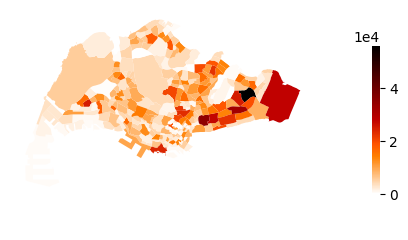

VH total = 2106284.570782499
PT total  = 4205907
ratio(mode/PT) = 0.5007919982021711
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


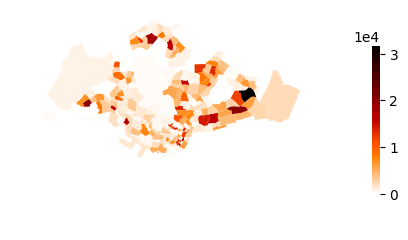

WK total = 966262.4686827576
PT total  = 4205907
ratio(mode/PT) = 0.22973938051477544
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742
Period tue
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


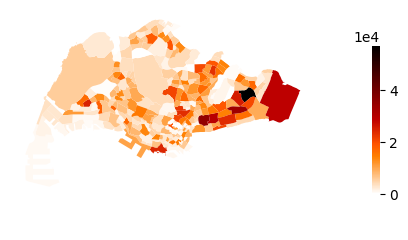

VH total = 2177900.7485269094
PT total  = 4349814
ratio(mode/PT) = 0.5006882474806761
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


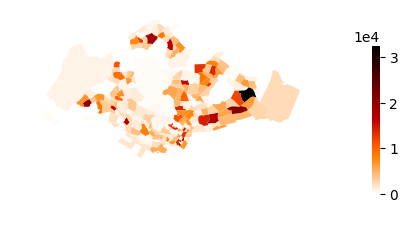

WK total = 1001111.9395746083
PT total  = 4349814
ratio(mode/PT) = 0.23015051668292216
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742
Period wed
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


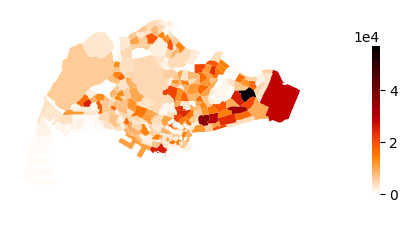

VH total = 2192446.351644934
PT total  = 4376526
ratio(mode/PT) = 0.5009558612572927
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


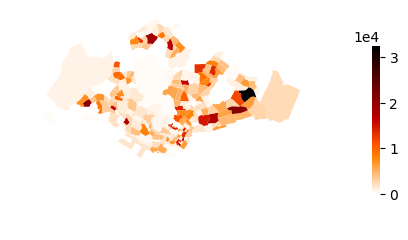

WK total = 1007154.7824727574
PT total  = 4376526
ratio(mode/PT) = 0.23012653928544177
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742
Period thu
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


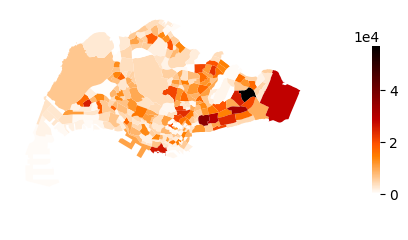

VH total = 2182204.428248709
PT total  = 4358190
ratio(mode/PT) = 0.5007134678039987
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


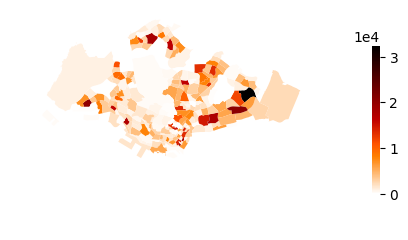

WK total = 1003069.4177608106
PT total  = 4358190
ratio(mode/PT) = 0.23015734003354846
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742
Period fri
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


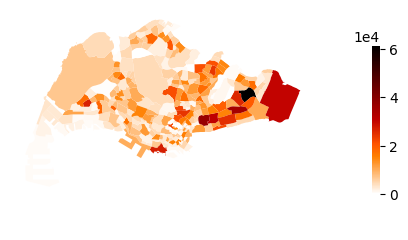

VH total = 2254708.039984048
PT total  = 4506101
ratio(mode/PT) = 0.500367843504628
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


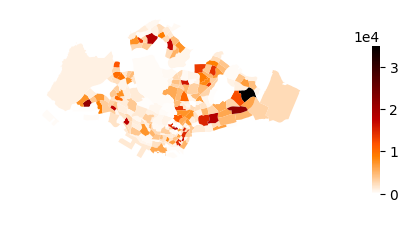

WK total = 1038746.6333183526
PT total  = 4506101
ratio(mode/PT) = 0.23052005121908112
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742
Period sat
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


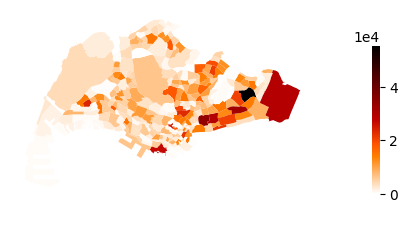

VH total = 1919489.4716556114
PT total  = 3877442
ratio(mode/PT) = 0.4950401506084711
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


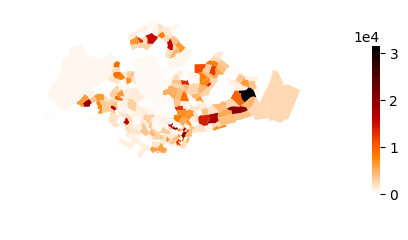

WK total = 907235.7507907259
PT total  = 3877442
ratio(mode/PT) = 0.23397790367740534
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742
Period sun
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


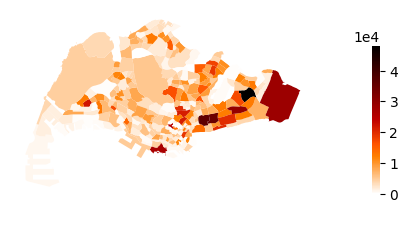

VH total = 1746883.2080939682
PT total  = 3502010
ratio(mode/PT) = 0.49882302109187815
Global median (mode/PT) ratio used for fallbacks = 0.5387931034482759
TRAVEL_MODE
PT    30312
VH    14976
WK     6839
Name: count, dtype: int64


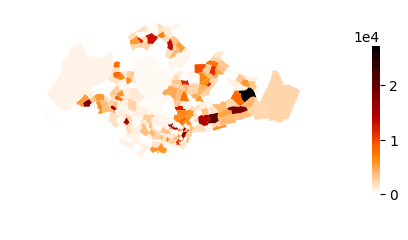

WK total = 812642.8286312867
PT total  = 3502010
ratio(mode/PT) = 0.23205040209230893
Global median (mode/PT) ratio used for fallbacks = 0.1935483870967742


In [ ]:
def plot_space_subzone(df_, att_, maxx):
    figx, figy = 5.5, 5.5

    # Load subzone geometries
    data_subzone = gpd.read_file(path_od_data + f'data_{reg}_subzone.shp')
    data_subzone = data_subzone[['SUBZONE_C', 'geometry']]

    # Merge counts into geometries
    df_geo = data_subzone.merge(df_, left_on='SUBZONE_C', right_on=att_, how='left')
    # Drop original attribute column but keep SUBZONE_C for labels
    df_geo.drop(columns=[att_], inplace=True)
    df_geo['COUNT'] = df_geo['COUNT'].fillna(0)

    # Prepare colormap and normalization
    norm = mpl.colors.Normalize(vmin=0, vmax=maxx)
    cmap = cm.get_cmap('gist_heat_r') #viridis gist_heat_r inferno plasma afmhot

    fig, ax = plt.subplots(figsize=(figx, figy))
    df_geo.plot(
        column='COUNT',
        cmap=cmap,
        norm=norm,
        ax=ax,
        edgecolor='none',
        linewidth=0,
        legend=True,
        alpha=1.0,
        antialiased=True,
        legend_kwds={'shrink': .35}
    )

    cbax = fig.axes[1]
    cbax.ticklabel_format(style='sci', scilimits=(0,0), axis='both')

    # --- Remove border line around colorbar ---
    for spine in cbax.spines.values():
        spine.set_visible(False)

    #data_subzone.plot(ax=ax, color='none', edgecolor='none') #black , linewidth=0.2

    ax.set_axis_off()
    fname = f'prior_{reg}_trip_generation.png'
    #plt.savefig(path_od_figure + fname, dpi=400, bbox_inches='tight')
    plt.show()

#######################################

week_days = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
modes = ['VH', 'WK']
reg = 'sgp'

for week_day in week_days:
    print(f'Period {week_day}')
    for mode in modes:
        # --- 1) Smart-card PT generation per origin ---
        df_sc = pd.read_csv(path_od_data + f'data_{reg}_sc_2022_period_{week_day}.csv', usecols=['ORIGIN_SUBZONE', 'COUNT'])
        df_sc = df_sc.groupby('ORIGIN_SUBZONE', as_index=False)['COUNT'].sum()  # PT counts by origin
        df_sc.to_csv(path_od_result + f'prior_{reg}_trip_generation_PT_{week_day}.csv', index=False)

        # --- 2) Load HTS and compute per-origin counts for PT and target mode ---
        df_hts = pd.read_csv(path_od_data + f'data_{reg}_hts_2022_period.csv')

        print(df_hts['TRAVEL_MODE'].value_counts())
        N_pt = len(df_hts[df_hts['TRAVEL_MODE'] == 'PT'])
        N_m = len(df_hts[df_hts['TRAVEL_MODE'] == mode])
        #print('ratio ', N_m/N_pt)

        # Count trips by origin for PT and for target mode
        pt_by_o = (df_hts.loc[df_hts['TRAVEL_MODE'] == 'PT', ['ORIGIN_SUBZONE']]
                        .groupby('ORIGIN_SUBZONE', as_index=False).size()
                        .rename(columns={'size': 'COUNT_PT'}))

        m_by_o = (df_hts.loc[df_hts['TRAVEL_MODE'] == mode, ['ORIGIN_SUBZONE']]
                        .groupby('ORIGIN_SUBZONE', as_index=False).size()
                        .rename(columns={'size': f'COUNT_{mode}'}))

        # --- 3) Per-origin ratio = COUNT_mode / COUNT_PT (from HTS) ---
        df_ratio = pt_by_o.merge(m_by_o, on='ORIGIN_SUBZONE', how='outer')
        df_ratio['COUNT_PT'] = df_ratio['COUNT_PT'].fillna(0)
        df_ratio[f'COUNT_{mode}'] = df_ratio[f'COUNT_{mode}'].fillna(0)

        # Raw ratio with safe division
        df_ratio['RATIO'] = np.where(df_ratio['COUNT_PT'] > 0,
                                    df_ratio[f'COUNT_{mode}'] / df_ratio['COUNT_PT'],
                                    np.nan)

        # Robust fallback for missing/undefined ratios:
        global_median = df_ratio['RATIO'].median(skipna=True)
        if np.isnan(global_median):
            global_median = 0.0  # if literally no info in HTS


        # --- 4) Apply ratio to smart-card PT counts to predict target-mode generation ---
        df = df_sc.merge(df_ratio[['ORIGIN_SUBZONE', 'RATIO']], on='ORIGIN_SUBZONE', how='left')
        df['RATIO'] = df['RATIO'].fillna(0)  # global_median unseen in HTS but present in SC

        #if mode == 'WK':
        #    df['RATIO'] = df['RATIO']
        df['COUNT'] = df['COUNT'] * df['RATIO']

        df_out = df[['ORIGIN_SUBZONE', 'COUNT']].copy()

        # --- 5) Save, plot, diagnostics ---
        df_out.to_csv(path_od_result + f'prior_{reg}_trip_generation_{mode}_{week_day}.csv', index=False)
        plot_space_subzone(df_out, 'ORIGIN_SUBZONE', df_out['COUNT'].max())

        print(f'{mode} total =', df_out['COUNT'].sum())
        print('PT total  =', df_sc['COUNT'].sum())
        if df_sc['COUNT'].sum() > 0:
            print('ratio(mode/PT) =', df_out['COUNT'].sum() / df_sc['COUNT'].sum())
        print('Global median (mode/PT) ratio used for fallbacks =', float(global_median))


## Temporal prior

Period mon


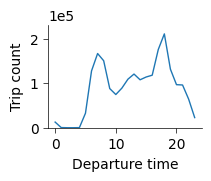

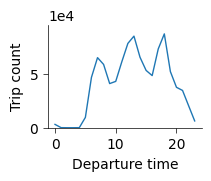

Period tue


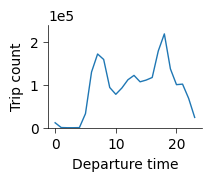

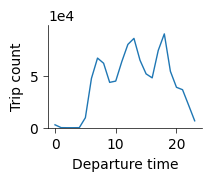

Period wed


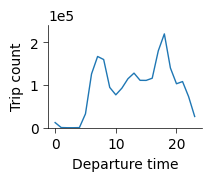

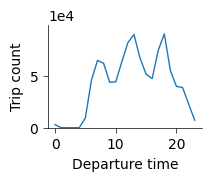

Period thu


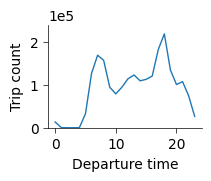

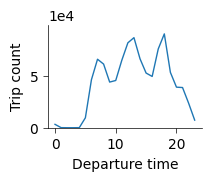

Period fri


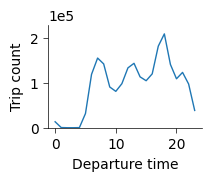

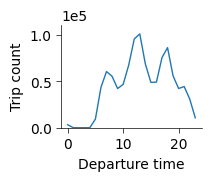

Period sat


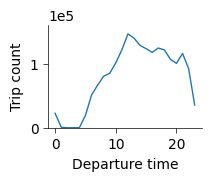

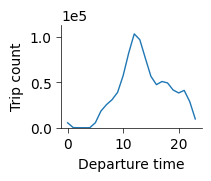

Period sun


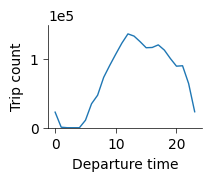

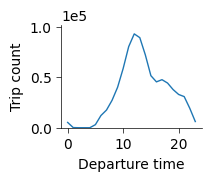

In [ ]:
def plot_departure_line(df_, maxz):
    """
    Plot departure time distribution as a professional line chart.

    Parameters
    ----------
    df_ : DataFrame
        Must contain ['TRIP_STARTTIME', 'COUNT'] columns.
    maxz : float
        Maximum y value (used for scaling the y-axis).
    """

    # -----------------------------
    # Data prep
    # -----------------------------
    df_plot = df_.copy()
    fig, ax = plt.subplots(figsize=(fig_x, fig_y), constrained_layout=True)

    # -----------------------------
    # Line plot
    # -----------------------------
    ax.plot(
        df_plot['TRIP_STARTTIME'],
        df_plot['COUNT'],
        #color='darkcyan',
        linewidth=1.0,
        #marker='o',
        #markersize=4,
        label="Trips"
    )

    # -----------------------------
    # Axis formatting
    # -----------------------------
    ax.set_ylim(0, maxz*1.1)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Labels
    ax.set_xlabel("Departure time")
    ax.set_ylabel("Trip count")

    # -----------------------------
    # Clean style
    # -----------------------------
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major')

    # -----------------------------
    # Clean style: thin spines
    # -----------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', width=0.5)

    # Legend
    #ax.legend(frameon=False)

    # -----------------------------
    # Export-ready
    # -----------------------------
    # out_path = path_od_figure + "prior_seoul_departure_time_line.png"
    # fig.savefig(out_path, dpi=600, bbox_inches='tight', facecolor='white')

    plt.show()


def estimate_all_mode_via_smoothing(
    survey_df,
    smartcard_df,
    window = 2
):
    """
    Estimate total (all-mode) trips per hour by smoothing the survey's PT share
    and scaling the smart-card PT counts.

    Parameters
    ----------
    survey_df : DataFrame
        Must contain columns [time_col, all_col, pt_col].
    smartcard_df : DataFrame
        Must contain columns [time_col, sc_col].
    time_col : str
        Name of the hour column (e.g. 'TRIP_STARTTIME').
    all_col : str
        Name of the survey's all-mode count column.
    pt_col : str
        Name of the survey's transit (PT) count column.
    sc_col : str
        Name of the smart-card transit count column.
    window : int
        Half‐window size for centered smoothing.  The smoother uses
        a window of length (2*window + 1).

    Returns
    -------
    DataFrame
        One row per hour, with columns:
          - time_col
          - phi_obs         : raw PT share from survey
          - phi_smooth      : smoothed PT share
          - COUNT_SC        : smart-card PT count
          - EST_COUNT_ALL   : estimated all-mode trips
    """

    time_col = 'TRIP_STARTTIME'
    all_col = 'COUNT_ALL'
    pt_col = 'COUNT_PT'
    sc_col = 'COUNT_SC'

    # 1) Compute raw PT share from survey
    df = survey_df[[time_col, all_col, pt_col]].copy()
    df['phi_obs'] = df[pt_col] / df[all_col]

    # 2) Smooth the share with a centered rolling window
    roll_len = 2 * window + 1
    df['phi_smooth'] = (
        df
        .sort_values(time_col)
        .set_index(time_col)['phi_obs']
        .rolling(window=roll_len, center=True, min_periods=1)
        .mean()
        .reset_index(drop=True)
    )

    # 3) Merge in smart-card counts
    result = (
        pd.merge(
            df[[time_col, 'phi_obs', 'phi_smooth']],
            smartcard_df[[time_col, sc_col]],
            on=time_col,
            how='left'
        )
    )

    # 4) Invert the smoothed share to estimate all-mode trips
    result['EST_COUNT_ALL'] = result[sc_col] / result['phi_smooth']

    return result

###############################
colors = ['tab:red','darkcyan']
fig_x = 2
fig_y = 1.7

week_days = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
modes = ['VH', 'WK']
reg = 'sgp'

df_hts = pd.read_csv(path_od_data + f'data_{reg}_hts_2022_period.csv')
df_hts['COUNT'] = 1

for week_day in week_days:
    print(f'Period {week_day}')
    for mode in modes:
        df1_ = df_hts[df_hts['TRAVEL_MODE'] == mode]
        df1_ = df1_[['TRIP_STARTTIME', 'COUNT']]
        df1_['COUNT'] = df1_.groupby(['TRIP_STARTTIME'])['COUNT'].transform('sum')
        df1_.drop_duplicates(inplace = True)
        df1_.sort_values('TRIP_STARTTIME', inplace=True)
        df1_.rename(columns = {'COUNT':'COUNT_ALL'}, inplace = True)

        df2_ = df_hts[df_hts['TRAVEL_MODE'] == 'PT']
        df2_ = df2_[['TRIP_STARTTIME', 'COUNT']]
        df2_['COUNT'] = df2_.groupby(['TRIP_STARTTIME'])['COUNT'].transform('sum')
        df2_.drop_duplicates(inplace = True)
        df2_.sort_values('TRIP_STARTTIME', inplace=True)
        df2_.rename(columns = {'COUNT':'COUNT_PT'}, inplace = True)

        survey_df = pd.merge(df1_, df2_, on='TRIP_STARTTIME')

        df_sc = pd.read_csv(path_od_data + f'data_{reg}_sc_2022_period_{week_day}.csv')
        df_sc = df_sc[['TRIP_STARTTIME', 'COUNT']]
        df_sc['COUNT'] = df_sc.groupby(['TRIP_STARTTIME'])['COUNT'].transform('sum')
        df_sc.drop_duplicates(inplace = True)
        df_sc.sort_values('TRIP_STARTTIME', inplace=True)
        df_sc.to_csv(path_od_result + f'prior_{reg}_departure_time_PT_{week_day}.csv', index=False)
        df_sc.rename(columns = {'COUNT':'COUNT_SC'}, inplace = True)

        df = estimate_all_mode_via_smoothing(survey_df, df_sc)
        df.rename(columns = {'EST_COUNT_ALL':'COUNT'}, inplace = True)

        df = df[['TRIP_STARTTIME', 'COUNT']]

        df_trip_total = pd.read_csv(path_od_result + f'prior_{reg}_trip_generation_{mode}_{week_day}.csv')
        trip_total = df_trip_total['COUNT'].sum()
        df['COUNT'] = df['COUNT'] * trip_total / df['COUNT'].sum()

        df.to_csv(path_od_result + f'prior_{reg}_departure_time_{mode}_{week_day}.csv', index=False)

        plot_departure_line(df, df['COUNT'].max())

#=======================================================

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

# =============================================================================
# NEW: Destination land-use mix from HTS (H/W/O only)
# =============================================================================
def destination_land_use_mix(
    hts_df: pd.DataFrame,
    dest_col: str = "DESTINATION_SUBZONE",
    purpose_col: str = "TRIP_PURPOSE",
    purposes: tuple[str, ...] = ("H", "W", "O"),
    prefix: str = "LU",
) -> pd.DataFrame:
    """
    Destination land-use mix proxies as HTS destination-purpose shares.

    Output: [DESTINATION_SUBZONE, LU_H, LU_W, LU_O]
    """
    df = hts_df[[dest_col, purpose_col]].copy()
    df = df[df[purpose_col].isin(purposes)].copy()

    counts = (
        df.groupby([dest_col, purpose_col], as_index=False)
          .size()
          .rename(columns={"size": "N"})
    )

    total_n = counts["N"].sum()
    counts["Prob"] = counts["N"] / total_n

    denom = counts.groupby(dest_col)["Prob"].transform("sum")
    counts["Prob"] = counts["Prob"] / denom

    wide = (
        counts.pivot(index=dest_col, columns=purpose_col, values="Prob")
              .fillna(0.0)
              .reset_index()
    )

    rename_map = {p: f"{prefix}_{p}" for p in purposes if p in wide.columns}
    wide.rename(columns=rename_map, inplace=True)

    # Ensure all expected columns exist
    for p in purposes:
        col = f"{prefix}_{p}"
        if col not in wide.columns:
            wide[col] = 0.0

    return wide[[dest_col, f"{prefix}_H", f"{prefix}_W", f"{prefix}_O"]]


# =============================================================================
# Vectorized utilities (same as before)
# =============================================================================
EARTH_RADIUS_KM = 6371.0

def haversine_km(df: pd.DataFrame, coord_cols: list[str]) -> pd.Series:
    o_lon = np.radians(df[coord_cols[0]].to_numpy())
    d_lon = np.radians(df[coord_cols[1]].to_numpy())
    o_lat = np.radians(df[coord_cols[2]].to_numpy())
    d_lat = np.radians(df[coord_cols[3]].to_numpy())

    dlon = d_lon - o_lon
    dlat = d_lat - o_lat

    a = np.sin(dlat / 2.0) ** 2 + np.cos(o_lat) * np.cos(d_lat) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

def od_transit_demand_share(pt_cell_df: pd.DataFrame, cell_keys: list[str], pt_count_col: str = "PT_COUNT") -> pd.DataFrame:
    agg = (
        pt_cell_df[cell_keys + [pt_count_col]]
        .groupby(cell_keys, as_index=False)[pt_count_col]
        .sum()
    )
    total_pt = agg[pt_count_col].sum()
    agg["OD_TRANSIT_DEMAND"] = agg[pt_count_col] / total_pt
    return agg[cell_keys + ["OD_TRANSIT_DEMAND"]]

def attribute_transit_share(trips_df: pd.DataFrame, group_col: str, mode_col: str = "TRAVEL_MODE",
                           count_col: str = "COUNT", pt_label: str = "PT") -> pd.DataFrame:
    mode_agg = (
        trips_df[[group_col, mode_col, count_col]]
        .groupby([group_col, mode_col], as_index=False)[count_col]
        .sum()
    )

    total_count = mode_agg[count_col].sum()
    mode_agg["Prob"] = mode_agg[count_col] / total_count
    mode_agg["Prob"] = mode_agg["Prob"] / mode_agg.groupby(group_col)["Prob"].transform("sum")

    pt_only = mode_agg[mode_agg[mode_col] == pt_label].copy()
    out_col = f"{group_col}_TRANSIT_DEMAND"
    pt_only.rename(columns={"Prob": out_col}, inplace=True)
    return pt_only[[group_col, out_col]]

def attribute_demand_share(demand_df: pd.DataFrame, group_col: str, count_col: str = "COUNT") -> pd.DataFrame:
    agg = (
        demand_df[[group_col, count_col]]
        .groupby(group_col, as_index=False)[count_col]
        .sum()
    )
    total_count = agg[count_col].sum()
    agg["Prob"] = agg[count_col] / total_count
    out_col = f"{group_col}_DEMAND"
    agg.rename(columns={"Prob": out_col}, inplace=True)
    return agg[[group_col, out_col]]

def load_and_aggregate_cell_counts(filepath: str, cell_keys: list[str], raw_count_col: str,
                                  out_count_col: str, positive_only: bool = False,
                                  min_positive_col: str | None = None) -> pd.DataFrame:
    df = pd.read_csv(filepath)

    if positive_only and min_positive_col is not None:
        df = df[df[min_positive_col] > 0].copy()

    agg = (
        df[cell_keys + [raw_count_col]]
        .groupby(cell_keys, as_index=False)[raw_count_col]
        .sum()
    )
    agg[out_count_col] = np.round(agg[raw_count_col])
    return agg[cell_keys + [out_count_col]]

def load_subzone_centroids(shp_path: str, id_col_in_shp: str = "SUBZONE_C") -> pd.DataFrame:
    subzones_gdf = gpd.read_file(shp_path)
    centroids = subzones_gdf.geometry.centroid
    # Kept exactly as your earlier logic (Y uses centroid.x)
    return pd.DataFrame({
        "ORIGIN_SUBZONE": subzones_gdf[id_col_in_shp].to_numpy(),
        "ORIGIN_SUBZONE_X": centroids.x.to_numpy(),
        "ORIGIN_SUBZONE_Y": centroids.y.to_numpy(),
    })


# =============================================================================
# Settings (updated: add LU features)
# =============================================================================
MODEL_NAME = "xgboost"
REGION_ID = "seoul"

DAY_GROUP = 'mon'

CELL_KEYS = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]

SUBZONE_KEYS = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]
COORD_COLS = ["ORIGIN_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_X", "DESTINATION_SUBZONE_Y"]

# Add LU_H/W/O into your feature set
FEATURE_COLS = [
    "TRIP_DISTANCE",
    "TRIP_STARTTIME_",
    "OD_TRANSIT_DEMAND",
    "ORIGIN_SUBZONE_DEMAND",
    "DESTINATION_SUBZONE_DEMAND",
    "LU_H",
    "LU_W",
    "LU_O",
]

MIN_CELL_PT_COUNT = 1


# =============================================================================
# 1) Load OD–time cell counts (vehicle = TomTom, transit = PT)
# =============================================================================

cellular_path = path_od_result + f'case_{REGION_ID}_matrix_cellular.csv'
generated_path =path_od_result + f'case_{REGION_ID}_matrix_{MODEL_NAME}_{DAY_GROUP}_1.0.csv'

veh_cells_gt = load_and_aggregate_cell_counts(
    filepath=cellular_path,
    cell_keys=CELL_KEYS,
    raw_count_col="COUNT",
    out_count_col="COUNT",
)

pt_cells_gt = load_and_aggregate_cell_counts(
    filepath=generated_path,
    cell_keys=CELL_KEYS,
    raw_count_col="PT_COUNT",
    out_count_col="PT_COUNT",
    positive_only=True,
    min_positive_col="PT_COUNT",
)

# Align supports
common_cells = veh_cells_gt.merge(pt_cells_gt[CELL_KEYS].drop_duplicates(), on=CELL_KEYS, how="inner")[CELL_KEYS].drop_duplicates()
veh_cells_gt = veh_cells_gt.merge(common_cells, on=CELL_KEYS, how="inner")
pt_cells_gt = pt_cells_gt.merge(common_cells, on=CELL_KEYS, how="inner")

cell_counts_gt = veh_cells_gt.merge(pt_cells_gt, on=CELL_KEYS, how="inner")
cell_counts_gt = cell_counts_gt[cell_counts_gt["PT_COUNT"] >= MIN_CELL_PT_COUNT].copy()


# =============================================================================
# 2) Load auxiliary datasets (kept as in your snippet)
# =============================================================================

# -----------------------
# Load data
# -----------------------
vh_df = pd.read_csv(
    path_od_result + f"prior_{REGION_ID}_trip_generation_VH_mon.csv",
    usecols=["ORIGIN_SUBZONE", "COUNT"]
).rename(columns={"COUNT": "COUNT_VH"})

pt_df = pd.read_csv(
    path_od_result + f"prior_{REGION_ID}_trip_generation_WK_mon.csv",
    usecols=["ORIGIN_SUBZONE", "COUNT"]
).rename(columns={"COUNT": "COUNT_WK"})

wk_df = pd.read_csv(
    path_od_result + f"prior_{REGION_ID}_trip_generation_PT_mon.csv",
    usecols=["ORIGIN_SUBZONE", "COUNT"]
).rename(columns={"COUNT": "COUNT_PT"})

# -----------------------
# Merge on ORIGIN_SUBZONE
# -----------------------
merged_df = (
    vh_df
    .merge(pt_df, on="ORIGIN_SUBZONE", how="outer")
    .merge(wk_df, on="ORIGIN_SUBZONE", how="outer")
)

# -----------------------
# Compute average COUNT
# -----------------------
merged_df["COUNT"] = merged_df[["COUNT_VH", "COUNT_WK", "COUNT_PT"]].mean(axis=1)

# Optional: keep only final output
od_generation_df = merged_df[["ORIGIN_SUBZONE", "COUNT"]]
od_generation_df["DESTINATION_SUBZONE"] = od_generation_df["ORIGIN_SUBZONE"]

hts_df = pd.read_csv(path_od_data + f"data_{REGION_ID}_hts_2021_period.csv")



# =============================================================================
# 3) Preprocess HTS trips (kept as in your snippet)
# =============================================================================
hts_df = hts_df[hts_df["TRAVEL_MODE"] != "WK"].copy()

hts_trip_freq_df = hts_df.copy()
hts_trip_freq_df["COUNT"] = 1

pt_cells_for_features = cell_counts_gt[SUBZONE_KEYS + ["PT_COUNT", "COUNT"]].drop_duplicates().copy()

# Survey trip distance (kept)
hts_df["TRIP_DISTANCE"] = haversine_km(
    hts_df,
    coord_cols=["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
)

# Keep columns (kept)
hts_df = hts_df[SUBZONE_KEYS + COORD_COLS + ["TRIP_DISTANCE"]].copy()

pt_cells_for_features["TRIP_STARTTIME_"] = pt_cells_for_features["TRIP_STARTTIME"]
hts_df["TRIP_STARTTIME_"] = hts_df["TRIP_STARTTIME"]


# =============================================================================
# 4) Feature components (existing) + NEW: LU mix at destination
# =============================================================================
origin_pt_share_df = attribute_transit_share(hts_trip_freq_df, group_col="ORIGIN_SUBZONE")
dest_pt_share_df = attribute_transit_share(hts_trip_freq_df, group_col="DESTINATION_SUBZONE")

origin_demand_share_df = attribute_demand_share(od_generation_df, group_col="ORIGIN_SUBZONE")
dest_demand_share_df = attribute_demand_share(od_generation_df, group_col="DESTINATION_SUBZONE")

od_pt_demand_share_df = od_transit_demand_share(
    pt_cell_df=pt_cells_for_features,
    cell_keys=SUBZONE_KEYS,
    pt_count_col="PT_COUNT",
)

# NEW: destination land-use mix from HTS (H/W/O)
dest_lu_mix_df = destination_land_use_mix(
    hts_df=hts_trip_freq_df,          # uses TRIP_PURPOSE; you can also use hts_df (both are fine)
    dest_col="DESTINATION_SUBZONE",
    purpose_col="TRIP_PURPOSE",
    purposes=("H", "W", "O"),
    prefix="LU",
)

# Merge all into pt_cells_for_features
pt_cells_for_features = (
    pt_cells_for_features
    .merge(origin_pt_share_df, on="ORIGIN_SUBZONE", how="left")
    .merge(dest_pt_share_df, on="DESTINATION_SUBZONE", how="left")
    .merge(origin_demand_share_df, on="ORIGIN_SUBZONE", how="left")
    .merge(dest_demand_share_df, on="DESTINATION_SUBZONE", how="left")
    .merge(od_pt_demand_share_df, on=SUBZONE_KEYS, how="left")
    .merge(dest_lu_mix_df, on="DESTINATION_SUBZONE", how="left")
)

# Ensure LU columns exist and fill missing with 0.0 (robust if some destinations lack HTS samples)
for col in ["LU_H", "LU_W", "LU_O"]:
    if col not in pt_cells_for_features.columns:
        pt_cells_for_features[col] = 0.0
pt_cells_for_features[["LU_H", "LU_W", "LU_O"]] = pt_cells_for_features[["LU_H", "LU_W", "LU_O"]].fillna(0.0)


# =============================================================================
# 5) Add subzone centroid coordinates (kept)
# =============================================================================
subzone_shp_path = path_od_data + f"data_{REGION_ID}_subzone.shp"
origin_centroids_df = load_subzone_centroids(subzone_shp_path, id_col_in_shp="SUBZONE_C")

pt_cells_for_features = pt_cells_for_features.merge(origin_centroids_df, on="ORIGIN_SUBZONE", how="left")

dest_centroids_df = origin_centroids_df.rename(columns={
    "ORIGIN_SUBZONE": "DESTINATION_SUBZONE",
    "ORIGIN_SUBZONE_X": "DESTINATION_SUBZONE_X",
    "ORIGIN_SUBZONE_Y": "DESTINATION_SUBZONE_Y",
})
pt_cells_for_features = pt_cells_for_features.merge(dest_centroids_df, on="DESTINATION_SUBZONE", how="left")


# =============================================================================
# 6) OD distance for cells + final table (kept)
# =============================================================================
pt_cells_for_features["TRIP_DISTANCE"] = haversine_km(
    pt_cells_for_features,
    coord_cols=["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
)

final_cell_feature_df = pt_cells_for_features[SUBZONE_KEYS + COORD_COLS + FEATURE_COLS + ["PT_COUNT", "COUNT"]].copy()

print(final_cell_feature_df)

        ORIGIN_SUBZONE  DESTINATION_SUBZONE  TRIP_STARTTIME  ORIGIN_SUBZONE_X  \
0              1101053              1101053               0        126.970144   
1              1101053              1101053               4        126.970144   
2              1101053              1101053               5        126.970144   
3              1101053              1101053               6        126.970144   
4              1101053              1101053               7        126.970144   
...                ...                  ...             ...               ...   
989224         1125074              1125074              19        127.145907   
989225         1125074              1125074              20        127.145907   
989226         1125074              1125074              21        127.145907   
989227         1125074              1125074              22        127.145907   
989228         1125074              1125074              23        127.145907   

        ORIGIN_SUBZONE_Y  D

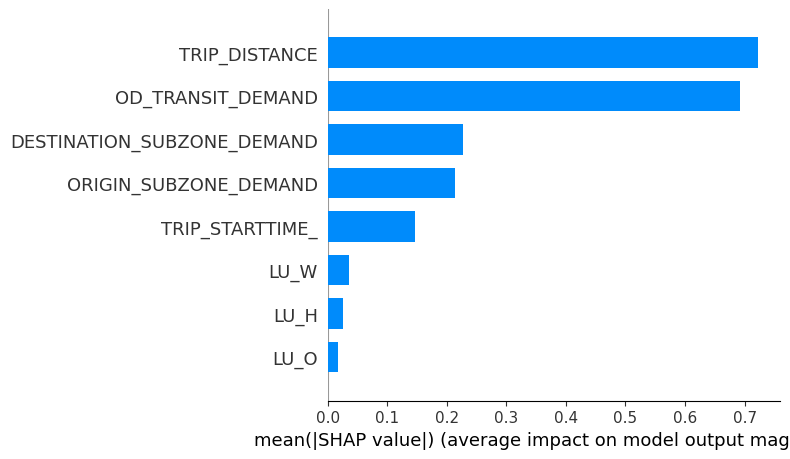

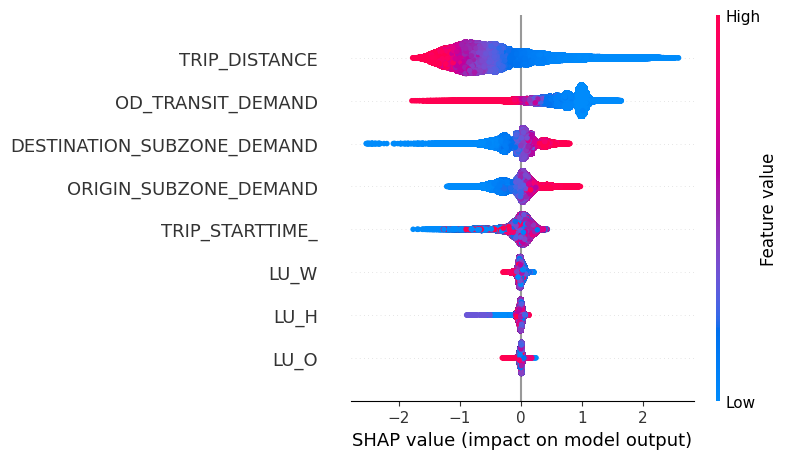


Feature-level SHAP importance (mean |SHAP|):
                      feature  mean_abs_shap
0               TRIP_DISTANCE       0.723275
1           OD_TRANSIT_DEMAND       0.691921
2  DESTINATION_SUBZONE_DEMAND       0.227197
3       ORIGIN_SUBZONE_DEMAND       0.213027
4             TRIP_STARTTIME_       0.145783
5                        LU_W       0.036437
6                        LU_H       0.025241
7                        LU_O       0.016526

Group-level SHAP importance (sum of mean |SHAP| within group):
             group  mean_abs_shap
0   Demand context       1.132145
1  Distance & time       0.869057
2     Land-use mix       0.078204


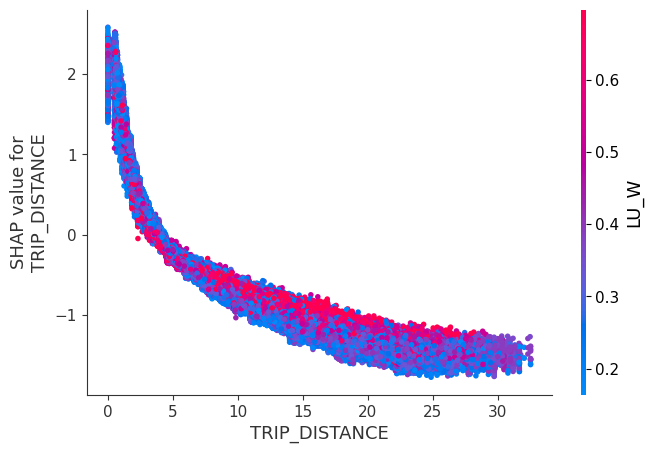

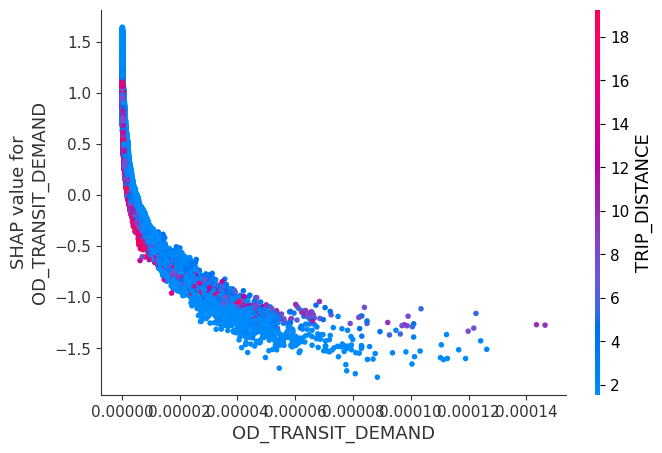

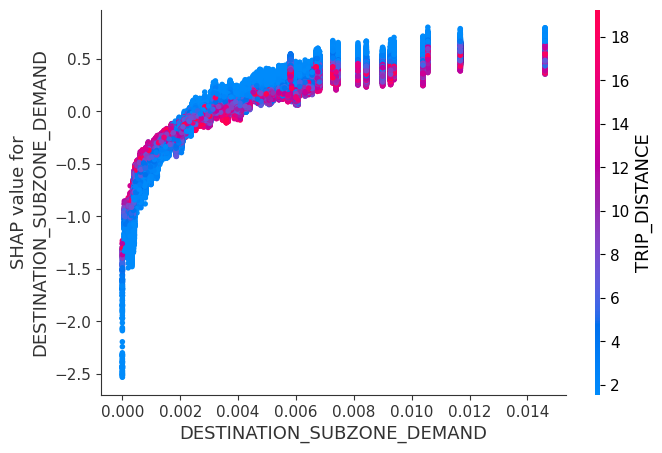

In [ ]:
# =============================================================================
# SHAP interpretability for cell-level ratio model: log((VH_COUNT+eps)/(PT_COUNT+eps))
# Assumes: final_cell_feature_df already exists with columns shown by you.
# =============================================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
import shap

# -----------------------------
# 0) Configuration
# -----------------------------
EPS = 1.0                 # stability constant for log-ratio
MIN_PT_COUNT = 1          # keep logic consistent with your pipeline; increase if needed
RANDOM_STATE = 42

# Features used for interpretability (exclude IDs, coords, and count columns)
RATIO_FEATURE_COLS = [
    "TRIP_DISTANCE",
    "TRIP_STARTTIME_",
    "OD_TRANSIT_DEMAND",
    "ORIGIN_SUBZONE_DEMAND",
    "DESTINATION_SUBZONE_DEMAND",
    "LU_H",
    "LU_W",
    "LU_O",
]

FEATURE_GROUPS = {
    "Distance & time": ["TRIP_DISTANCE", "TRIP_STARTTIME_"],
    "Demand context": ["OD_TRANSIT_DEMAND", "ORIGIN_SUBZONE_DEMAND", "DESTINATION_SUBZONE_DEMAND"],
    "Land-use mix": ["LU_H", "LU_W", "LU_O"],
}

# -----------------------------
# 1) Prepare data
# -----------------------------
ratio_df = final_cell_feature_df.copy()

# Basic filtering for stability (optional but recommended)
ratio_df = ratio_df[ratio_df["PT_COUNT"] >= MIN_PT_COUNT].copy()

# Target: log-ratio
ratio_df["LOG_ALL_PT_RATIO"] = np.log(
    (ratio_df["COUNT"] + EPS) / (ratio_df["PT_COUNT"] + EPS)
)

# Sample weights (recommended): emphasize cells with more PT exposure
ratio_df["SAMPLE_WEIGHT"] = ratio_df["PT_COUNT"].astype(float)

# Feature matrix / target / weights
X = ratio_df[RATIO_FEATURE_COLS].copy()
y = ratio_df["LOG_ALL_PT_RATIO"].astype(float)
w = ratio_df["SAMPLE_WEIGHT"].astype(float)

# Ensure numeric (defensive)
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0.0)

# -----------------------------
# 2) Train XGBoost regression model (for interpretability)
# -----------------------------
ratio_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

ratio_model.fit(X, y, sample_weight=w)

# Optional quick sanity check (in-sample)
# from sklearn.metrics import r2_score
# print("In-sample R2 (weighted):", r2_score(y, ratio_model.predict(X), sample_weight=w))

# -----------------------------
# 3) Compute SHAP values
# -----------------------------
# TreeExplainer is appropriate for XGBoost tree models.
explainer = shap.TreeExplainer(ratio_model)
shap_values = explainer.shap_values(X)  # shape: (n_samples, n_features)

# -----------------------------
# 4) Global SHAP plots
# -----------------------------
# (A) Global feature importance (bar)
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=True,
)

# (B) Standard summary plot (beeswarm)
shap.summary_plot(
    shap_values,
    X,
    show=True,
)

# -----------------------------
# 5) Tabular importance: feature-level and group-level
# -----------------------------
# Feature-level mean(|SHAP|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance_df = (
    pd.DataFrame({"feature": X.columns, "mean_abs_shap": mean_abs_shap})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)

print("\nFeature-level SHAP importance (mean |SHAP|):")
print(feature_importance_df)

# Group-level mean(|SHAP|) by summing feature importances within groups
group_rows = []
for group_name, group_features in FEATURE_GROUPS.items():
    group_value = feature_importance_df.loc[
        feature_importance_df["feature"].isin(group_features),
        "mean_abs_shap"
    ].sum()
    group_rows.append({"group": group_name, "mean_abs_shap": group_value})

group_importance_df = (
    pd.DataFrame(group_rows)
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)

print("\nGroup-level SHAP importance (sum of mean |SHAP| within group):")
print(group_importance_df)

# -----------------------------
# 6) Optional: dependence plots for key drivers
# -----------------------------
# Pick top 1–3 features automatically
top_features = feature_importance_df["feature"].head(3).tolist()

for f in top_features:
    shap.dependence_plot(
        f,
        shap_values,
        X,
        show=True,
    )

# -----------------------------
# 7) Optional: export importance tables to CSV (useful for manuscript figures/tables)
# -----------------------------
# feature_importance_df.to_csv("shap_feature_importance.csv", index=False)
# group_importance_df.to_csv("shap_group_importance.csv", index=False)


# Pipline with reference mode = transit mode (Smartcard)


## Pipeline

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


# ============================================================
# Stage A: ML ratio model (unchanged logic)
# ============================================================
def predict_ratio_to_smartcard_xgb(survey_df: pd.DataFrame, smartcard_df: pd.DataFrame):
    """
    Train XGBoost on survey_df to predict 'RATIO', then predict for smartcard_df.
    Returns smartcard_df with ['TRIP_DISTANCE','OT_COUNT','PT_COUNT'] (plus keys/coords).
    NOTE: Uses global att_cluster, att_subzone, att_coordinate (same as your original).
    """
    target_col = "RATIO"
    if target_col not in survey_df.columns:
        raise ValueError(f"'{target_col}' not found in survey_df")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(survey_df[att_cluster])
    X_train = pd.DataFrame(X_train_scaled, columns=att_cluster).values
    y_train = survey_df[target_col]

    model = XGBRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    )
    model.fit(X_train, y_train)

    X_pred_scaled = scaler.transform(smartcard_df[att_cluster])
    X_pred = pd.DataFrame(X_pred_scaled, columns=att_cluster).values

    preds = model.predict(X_pred)
    preds = np.maximum(preds, 0)

    smartcard_df = smartcard_df.copy()
    smartcard_df[target_col] = preds
    smartcard_df["OT_COUNT"] = smartcard_df[target_col] * smartcard_df["PT_COUNT"]

    return smartcard_df[att_subzone + att_coordinate + ["TRIP_DISTANCE", "OT_COUNT", "PT_COUNT"]]


def compute_distance(df: pd.DataFrame, att: list[str]) -> np.ndarray:
    """
    Haversine distance in km.
    att = [origin_lon, dest_lon, origin_lat, dest_lat]
    """
    lon1 = np.radians(df[att[0]])
    lon2 = np.radians(df[att[1]])
    lat1 = np.radians(df[att[2]])
    lat2 = np.radians(df[att[3]])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


def od_transit_share(df: pd.DataFrame) -> pd.DataFrame:
    df_mode = df[["ORIGIN_SUBZONE", "TRIP_STARTTIME", "DESTINATION_SUBZONE", "PT_COUNT"]].copy()
    df_mode["PT_COUNT"] = df_mode.groupby(
        ["ORIGIN_SUBZONE", "TRIP_STARTTIME", "DESTINATION_SUBZONE"]
    )["PT_COUNT"].transform("sum")
    df_mode = df_mode.drop_duplicates()
    df_mode["OD_TRANSIT_DEMAND"] = df_mode["PT_COUNT"] / df_mode["PT_COUNT"].sum()
    df_mode = df_mode.drop(columns=["PT_COUNT"])
    return df_mode


def transit_mode_share(df: pd.DataFrame, att: str) -> pd.DataFrame:
    df_mode = df[[att, "TRAVEL_MODE", "COUNT"]].copy()
    df_mode = df_mode.groupby([att, "TRAVEL_MODE"], as_index=False)["COUNT"].sum()
    df_mode = df_mode.drop_duplicates()

    total_count = df_mode["COUNT"].sum()
    df_mode["Prob"] = df_mode["COUNT"] / total_count
    df_mode = df_mode.drop(columns=["COUNT"])

    df_mode["Prob"] /= df_mode.groupby(att)["Prob"].transform("sum")

    df_mode = df_mode[df_mode["TRAVEL_MODE"] == "PT"]
    df_mode = df_mode.rename(columns={"Prob": att + "_TRANSIT_DEMAND"})
    df_mode = df_mode.drop(columns=["TRAVEL_MODE"])
    return df_mode


def demand_share(df: pd.DataFrame, att: str) -> pd.DataFrame:
    df_demand = df[[att, "COUNT"]].copy()
    df_demand = df_demand.groupby([att], as_index=False)["COUNT"].sum()
    df_demand = df_demand.drop_duplicates()

    total_count = df_demand["COUNT"].sum()
    df_demand["Prob"] = df_demand["COUNT"] / total_count
    df_demand = df_demand.drop(columns=["COUNT"])
    df_demand = df_demand.rename(columns={"Prob": att + "_DEMAND"})
    return df_demand

def add_mode_ratio_with_smooth(
    survey_df: pd.DataFrame,
    walk_mode: bool = False,
    walk_threshold: float = 5,
    clip_ratio_value=5,
    lambdaa: float = 5,
    eps: float = 1e-9,
) -> pd.DataFrame:
    """
    Smoothed OT/PT ratio per (ORIGIN_SUBZONE, DESTINATION_SUBZONE, TRIP_STARTTIME).
    NOTE: identical logic to your original (kept).
    """
    transit_df = survey_df.loc[survey_df["TRAVEL_MODE"] == "PT", att_subzone].copy()
    transit_df["PT_COUNT"] = 1
    transit_df["PT_COUNT"] = transit_df.groupby(att_subzone)["PT_COUNT"].transform("sum")
    transit_df = transit_df[att_subzone + ["PT_COUNT"]].drop_duplicates()

    other_df = survey_df.loc[survey_df["TRAVEL_MODE"] == "OT", att_subzone].copy()
    other_df["OT_COUNT"] = 1
    other_df["OT_COUNT"] = other_df.groupby(att_subzone)["OT_COUNT"].transform("sum")
    other_df = other_df[att_subzone + ["OT_COUNT"]].drop_duplicates()

    survey_df_ = survey_df.copy()
    survey_df_ = survey_df_.merge(transit_df, on=att_subzone)
    survey_df_ = survey_df_.merge(other_df, on=att_subzone)
    survey_df_["COUNT"] = survey_df_["PT_COUNT"] + survey_df_["OT_COUNT"]
    survey_df_["RATIO"] = survey_df_["OT_COUNT"] / (survey_df_["PT_COUNT"] + eps)

    orig_pivot = (
        survey_df.groupby(["ORIGIN_SUBZONE", "TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_O", "OT": "OT_O"})
        .reset_index()
    )
    orig_pivot["mu_O"] = orig_pivot["OT_O"] / (orig_pivot["PT_O"] + eps)

    dest_pivot = (
        survey_df.groupby(["DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_D", "OT": "OT_D"})
        .reset_index()
    )
    dest_pivot["mu_D"] = dest_pivot["OT_D"] / (dest_pivot["PT_D"] + eps)

    global_time = (
        survey_df.groupby(["TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_T", "OT": "OT_T"})
        .reset_index()
    )
    global_time["mu_T"] = global_time["OT_T"] / (global_time["PT_T"] + eps)

    survey_df_ = survey_df_.merge(
        orig_pivot[["ORIGIN_SUBZONE", "TRIP_STARTTIME", "mu_O", "PT_O"]],
        on=["ORIGIN_SUBZONE", "TRIP_STARTTIME"],
        how="left",
    )
    survey_df_ = survey_df_.merge(
        dest_pivot[["DESTINATION_SUBZONE", "TRIP_STARTTIME", "mu_D", "PT_D"]],
        on=["DESTINATION_SUBZONE", "TRIP_STARTTIME"],
        how="left",
    )
    survey_df_ = survey_df_.merge(
        global_time[["TRIP_STARTTIME", "mu_T"]],
        on="TRIP_STARTTIME",
        how="left",
    )

    w_o = survey_df_["PT_O"].fillna(0.0)
    w_d = survey_df_["PT_D"].fillna(0.0)
    w_sum = w_o + w_d

    mu_blend = (w_o * survey_df_["mu_O"] + w_d * survey_df_["mu_D"]) / (w_sum.replace(0, np.nan))

    mu = (
        mu_blend.fillna(survey_df_["mu_O"])
        .fillna(survey_df_["mu_D"])
        .fillna(survey_df_["mu_T"])
        .fillna(0.0)
    )

    scale_val = survey_df_["COUNT"].quantile(0.98)
    p = lambdaa

    survey_df_["ww2"] = (survey_df_["COUNT"] / scale_val) ** p
    survey_df_["ww2"] = survey_df_["ww2"].clip(lower=0.0, upper=1.0)

    survey_df_["RATIO"] = survey_df_["ww2"] * survey_df_["RATIO"] + (1 - survey_df_["ww2"]) * mu
    survey_df_ = survey_df_.drop(columns=["ww2"])

    if walk_mode:
        survey_df_.loc[survey_df_["TRIP_DISTANCE"] >= walk_threshold, "RATIO"] = 0

    #if clip_ratio_value is not None:
    #    survey_df_["RATIO"] = survey_df_["RATIO"].clip(upper=clip_ratio_value * mu)

    survey_df_["OT_COUNT"] = survey_df_["PT_COUNT"] * survey_df_["RATIO"]
    survey_df_ = survey_df_.drop(columns=["mu_O", "mu_D", "mu_T", "PT_O", "PT_D"], errors="ignore")

    return survey_df_


# ============================================================
# Stage B: Marginal fitting / combination (unchanged logic)
# ============================================================
def _circular_kernel(hours: int, bandwidth: float) -> np.ndarray:
    hrs = np.arange(hours)
    D = np.abs(hrs[:, None] - hrs[None, :])
    D = np.minimum(D, hours - D)
    K = np.exp(-0.5 * (D / float(bandwidth)) ** 2)
    K /= K.sum(axis=1, keepdims=True)
    return K


def fit_to_marginals_3way(
    df: pd.DataFrame,
    global_departures,
    origin_totals,
    destination_totals,
    smooth_seed: bool = True,
    bandwidth: float = 5,
    origin_col: str = "ORIGIN_SUBZONE",
    dest_col: str = "DESTINATION_SUBZONE",
    time_col: str = "TRIP_STARTTIME",
    ot_col: str = "COUNT",
    hours: int = 24,
    max_iter: int = 1000,
    tol: float = 1e-10,
) -> pd.DataFrame:
    # --- Prepare inputs ---
    if isinstance(global_departures, pd.Series):
        if global_departures.index.dtype.kind in {"i", "u"}:
            G = global_departures.reindex(range(hours)).to_numpy(float)
        else:
            G = global_departures.to_numpy(float)
    else:
        G = np.asarray(global_departures, dtype=float)
    if G.shape[0] != hours:
        raise ValueError("global_departures must have length = `hours`.")

    O_map = origin_totals.to_dict() if isinstance(origin_totals, pd.Series) else dict(origin_totals)
    D_map = destination_totals.to_dict() if isinstance(destination_totals, pd.Series) else dict(destination_totals)

    T_g, T_o, T_d = G.sum(), np.sum(list(O_map.values())), np.sum(list(D_map.values()))
    if T_g <= 0 or T_o <= 0 or T_d <= 0:
        raise ValueError("All marginals must have positive totals.")
    target_total = 0.5 * (T_o + T_d)
    if not np.isclose(T_g, target_total):
        G = G * (target_total / T_g)

    # --- Duplicates handling ---
    out = df.copy()
    out["_orig_order__"] = np.arange(len(out))
    key_cols = [origin_col, dest_col, time_col]

    grp_sum = out.groupby(key_cols, as_index=False)[ot_col].sum().rename(columns={ot_col: "__agg"})
    tot_per_key = out.groupby(key_cols)[ot_col].transform("sum")
    cnt_per_key = out.groupby(key_cols)[ot_col].transform("size")
    out["__w"] = np.where(tot_per_key > 0, out[ot_col] / tot_per_key, 1.0 / cnt_per_key)

    # --- Build cube ---
    origins = grp_sum[origin_col].unique().tolist()
    dests = grp_sum[dest_col].unique().tolist()
    O, D, H = len(origins), len(dests), hours

    o2i = {o: i for i, o in enumerate(origins)}
    d2j = {d: j for j, d in enumerate(dests)}

    X = np.zeros((O, D, H), dtype=float)
    for _, row in grp_sum.iterrows():
        i = o2i[row[origin_col]]
        j = d2j[row[dest_col]]
        t = int(row[time_col])
        if 0 <= t < H:
            X[i, j, t] = row["__agg"]
        else:
            raise ValueError(f"Hour {t} out of [0,{H-1}].")

    Seed = X.copy()
    if smooth_seed:
        K = _circular_kernel(H, bandwidth)
        Seed = np.tensordot(Seed, K.T, axes=(2, 0))
        S0 = X.sum(axis=2, keepdims=True)
        S1 = Seed.sum(axis=2, keepdims=True)
        Seed *= np.divide(S0, np.maximum(S1, 1e-16))

    O_vec = np.array([O_map.get(o, 0.0) for o in origins], dtype=float)
    D_vec = np.array([D_map.get(d, 0.0) for d in dests], dtype=float)

    target_total = G.sum()
    seed_total = Seed.sum()
    if seed_total <= 0:
        raise ValueError("Seed has zero total.")
    Seed *= (target_total / seed_total)

    # --- IPF ---
    Y = Seed.copy()
    eps = 1e-16
    for _ in range(max_iter):
        row_o = Y.sum(axis=(1, 2))
        Y *= np.divide(O_vec, np.maximum(row_o, eps))[:, None, None]

        col_d = Y.sum(axis=(0, 2))
        Y *= np.divide(D_vec, np.maximum(col_d, eps))[None, :, None]

        col_t = Y.sum(axis=(0, 1))
        Y *= np.divide(G, np.maximum(col_t, eps))[None, None, :]

        err_t = np.max(np.abs(Y.sum(axis=(0, 1)) - G))
        err_o = np.max(np.abs(Y.sum(axis=(1, 2)) - O_vec))
        err_d = np.max(np.abs(Y.sum(axis=(0, 2)) - D_vec))
        if max(err_t, err_o, err_d) < tol:
            break

    records = []
    for i, o in enumerate(origins):
        for j, d in enumerate(dests):
            for t in range(H):
                if Y[i, j, t] != 0.0:
                    records.append((o, d, t, Y[i, j, t]))
    Y_long = pd.DataFrame(records, columns=[origin_col, dest_col, time_col, "__fit_odt"])

    out = out.merge(Y_long, on=[origin_col, dest_col, time_col], how="left")
    out[ot_col] = out["__fit_odt"] * out["__w"]
    out = out.sort_values("_orig_order__").drop(columns=["_orig_order__", "__w", "__fit_odt"])
    return out


# ============================================================
# Combined pipeline: Stage A (ML) + Stage B (IPF + merge)
# ============================================================
def run_combined_pipeline(
    *,
    path_od_result: str,
    path_od_data: str,
    reg: str = "sgp",
    week_days: list[str] = None,
    k_values: list[float] = None,
    modes: list[str] = None,
    model_name: str = "xgboost",
    sample_frac: float = 0.6,
    random_state: int = 42,
    wk_threshold: float = 3.5,
    clip_ratio=None,
    bwidth: float = 2,
    n_time: int = 24,
    smooth_seed: bool = True,
):
    """
    Runs BOTH pipelines end-to-end per week_day and k:
      1) ML ratio learning (survey) -> OT_COUNT on smartcard support for modes in `modes`
      2) Marginal fitting (IPF) per mode using prior G/O/D, then merge with PT_COUNT

    Outputs (same naming pattern you used):
      - Intermediate: case_{reg}_matrix_{model}_{sample_frac}_{mode}_{week_day}_{k}.csv
      - Final:        case_{reg}_matrix_{model}_{sample_frac}_{week_day}_{k}.csv
    """

    global att_subzone, att_coordinate, att_cluster

    # --- Defaults to match your scripts ---
    if week_days is None:
        week_days = ["mon", "tue", "wed"]
    if k_values is None:
        k_values = [round(i * 0.2, 1) for i in range(5, 6)]  # -> [1.0]
    if modes is None:
        modes = ["WK", "VH"]

    # --- Feature specs used by Stage A (your first pipeline) ---
    att_subzone = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]
    att_coordinate = ["ORIGIN_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_X", "DESTINATION_SUBZONE_Y"]
    att_cluster = ["TRIP_DISTANCE", "TRIP_STARTTIME_", "OD_TRANSIT_DEMAND", "ORIGIN_SUBZONE_DEMAND", "DESTINATION_SUBZONE_DEMAND"]

    start_time = time.time()

    for week_day in week_days:
        print(f"week_day = {week_day}")

        # --- Load priors needed for Stage B (your second pipeline) ---
        od_vh = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_VH_{week_day}.csv")
        od_vh["DESTINATION_SUBZONE"] = od_vh["ORIGIN_SUBZONE"]
        td_vh = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_VH_{week_day}.csv")

        od_wk = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_WK_{week_day}.csv")
        od_wk["DESTINATION_SUBZONE"] = od_wk["ORIGIN_SUBZONE"]
        td_wk = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_WK_{week_day}.csv")

        od_pt = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_PT_{week_day}.csv")
        od_pt["DESTINATION_SUBZONE"] = od_pt["ORIGIN_SUBZONE"]
        td_pt = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_PT_{week_day}.csv")

        G_VH = td_vh.groupby("TRIP_STARTTIME")["COUNT"].sum().reindex(range(n_time), fill_value=0.0)
        O_VH = od_vh.groupby("ORIGIN_SUBZONE")["COUNT"].sum()
        D_VH = od_vh.groupby("DESTINATION_SUBZONE")["COUNT"].sum()

        G_WK = td_wk.groupby("TRIP_STARTTIME")["COUNT"].sum().reindex(range(n_time), fill_value=0.0)
        O_WK = od_wk.groupby("ORIGIN_SUBZONE")["COUNT"].sum()
        D_WK = od_wk.groupby("DESTINATION_SUBZONE")["COUNT"].sum()

        total_count_vh = od_vh["COUNT"].sum()
        total_count_wk = od_wk["COUNT"].sum()
        total_count_pt = od_pt["COUNT"].sum()

        # PT base (smartcard)
        sc_df = pd.read_csv(path_od_data + f"data_{reg}_sc_2022_period_{week_day}.csv")
        sc_df = sc_df[["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "COUNT"]].copy()
        sc_df.rename(columns={"COUNT": "PT_COUNT"}, inplace=True)

        print("total_count_vh", total_count_vh)
        print("total_count_wk", total_count_wk)
        print("total_count_pt", total_count_pt)

        for k in k_values:
            print(f"k = {k}")

            # ============================================================
            # Stage A: ML ratio -> OT_COUNT for each target mode
            # ============================================================
            stageA_outputs = {}  # mode -> DataFrame with OT_COUNT

            for mode in modes:
                print(f"  [Stage A] mode = {mode}")

                od_demand_df = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_{mode}_{week_day}.csv")
                od_demand_df["DESTINATION_SUBZONE"] = od_demand_df["ORIGIN_SUBZONE"]

                smartcard_df = pd.read_csv(path_od_data + f"data_{reg}_sc_2022_period_{week_day}.csv")
                survey_df = pd.read_csv(path_od_data + f"data_{reg}_hts_2022_period.csv")

                # Mode mapping (unchanged)
                if mode == "VH":
                    survey_df = survey_df[survey_df["TRAVEL_MODE"] != "WK"]
                    survey_df.replace({"VH": "OT"}, inplace=True)
                elif mode == "WK":
                    survey_df = survey_df[survey_df["TRAVEL_MODE"] != "VH"]
                    survey_df.replace({"WK": "OT"}, inplace=True)

                n_pt = len(survey_df[survey_df["TRAVEL_MODE"] == "PT"])
                n_ot = len(survey_df[survey_df["TRAVEL_MODE"] == "OT"])
                current_mode_ratio = n_ot / n_pt if n_pt > 0 else np.nan
                print(f"    Current mode ratio: {current_mode_ratio}")

                attribute_df = survey_df.copy()
                attribute_df["COUNT"] = 1

                smartcard_df.rename(columns={"COUNT": "PT_COUNT"}, inplace=True)
                smartcard_df["PT_COUNT"] = smartcard_df.groupby(att_subzone)["PT_COUNT"].transform("sum")
                smartcard_df = smartcard_df[att_subzone + att_coordinate + ["PT_COUNT"]].drop_duplicates()

                survey_df["TRIP_DISTANCE"] = compute_distance(
                    survey_df,
                    ["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
                )

                wk_mode = (mode == "WK")

                if sample_frac < 1:
                    survey_df = (
                        survey_df.sample(frac=sample_frac, random_state=random_state)
                        .reset_index(drop=True)
                    )

                survey_df = add_mode_ratio_with_smooth(
                    survey_df.copy(),
                    walk_mode=wk_mode,
                    walk_threshold=wk_threshold,
                    clip_ratio_value=clip_ratio,
                    lambdaa=k,
                )

                print(f'    HTS sample size for sample_frac={sample_frac}: {len(survey_df)}')

                survey_df = survey_df[att_subzone + att_coordinate + ["RATIO", "TRIP_DISTANCE"]]

                smartcard_df["TRIP_STARTTIME_"] = smartcard_df["TRIP_STARTTIME"]
                survey_df["TRIP_STARTTIME_"] = survey_df["TRIP_STARTTIME"]

                mode_origin = transit_mode_share(attribute_df, "ORIGIN_SUBZONE")
                mode_destination = transit_mode_share(attribute_df, "DESTINATION_SUBZONE")
                demand_origin = demand_share(od_demand_df, "ORIGIN_SUBZONE")
                demand_destination = demand_share(od_demand_df, "DESTINATION_SUBZONE")
                demand_od = od_transit_share(smartcard_df)

                smartcard_feat = (
                    smartcard_df.merge(mode_origin)
                    .merge(mode_destination)
                    .merge(demand_origin)
                    .merge(demand_destination)
                    .merge(demand_od)
                )
                smartcard_feat["TRIP_DISTANCE"] = compute_distance(
                    smartcard_feat,
                    ["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
                )
                smartcard_feat = smartcard_feat[att_subzone + att_coordinate + att_cluster + ["PT_COUNT"]]

                survey_feat = (
                    survey_df.merge(mode_origin)
                    .merge(mode_destination)
                    .merge(demand_origin)
                    .merge(demand_destination)
                    .merge(demand_od)
                )

                smartcard_out = predict_ratio_to_smartcard_xgb(survey_feat, smartcard_feat)

                if mode == "WK":
                    smartcard_out.loc[smartcard_out["TRIP_DISTANCE"] >= wk_threshold, "OT_COUNT"] = 0

                smartcard_out = smartcard_out.drop(columns=["TRIP_DISTANCE"])

                #file_intermediate = path_od_result + f"case_{reg}_matrix_{model_name}_{sample_frac}_{mode}_{week_day}_{k}.csv"
                #smartcard_out.to_csv(file_intermediate, index=False)

                stageA_outputs[mode] = smartcard_out

            # ============================================================
            # Stage B: IPF to marginals + combine with PT
            # ============================================================
            print(f"  [Stage B] IPF + merge modes (k={k})")

            # Read from memory (or you can read files again; logic identical)
            df_vh = stageA_outputs["VH"][["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "OT_COUNT"]].copy()
            df_wk = stageA_outputs["WK"][["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "OT_COUNT"]].copy()

            df_vh.rename(columns={"OT_COUNT": "COUNT"}, inplace=True)
            df_wk.rename(columns={"OT_COUNT": "COUNT"}, inplace=True)

            # Renormalize to prior totals (unchanged)
            df_vh["COUNT"] = df_vh["COUNT"] * total_count_vh / df_vh["COUNT"].sum()
            df_wk["COUNT"] = df_wk["COUNT"] * total_count_wk / df_wk["COUNT"].sum()

            # IPF fits
            df_vh = fit_to_marginals_3way(df_vh, G_VH, O_VH, D_VH, smooth_seed=smooth_seed, bandwidth=bwidth)
            df_wk = fit_to_marginals_3way(df_wk, G_WK, O_WK, D_WK, smooth_seed=smooth_seed, bandwidth=bwidth)

            # Renormalize again (unchanged)
            df_vh["COUNT"] = df_vh["COUNT"] * total_count_vh / df_vh["COUNT"].sum()
            df_wk["COUNT"] = df_wk["COUNT"] * total_count_wk / df_wk["COUNT"].sum()

            df_vh.rename(columns={"COUNT": "VH_COUNT"}, inplace=True)
            df_wk.rename(columns={"COUNT": "WK_COUNT"}, inplace=True)

            result_df = sc_df.merge(df_vh, on=["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"], how="outer")
            result_df = result_df.merge(df_wk, on=["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"], how="outer")
            result_df = result_df.fillna(0)

            result_df["COUNT"] = result_df["PT_COUNT"] + result_df["VH_COUNT"] + result_df["WK_COUNT"]
            print("    result_df total COUNT =", result_df["COUNT"].sum())

            file_final = path_od_result + f"case_{reg}_matrix_{sample_frac}_{k}_{week_day}.csv"
            result_df.to_csv(file_final, index=False)

    elapsed = time.time() - start_time
    print(f"Elapsed time: {elapsed:.2f} seconds")


# ============================================================
# Example call
# ============================================================

# for diferent k
'''for frac in range(10, 11):
    run_combined_pipeline(
        path_od_result=path_od_result,
        path_od_data=path_od_data,
        reg="sgp",
        week_days=["mon", "tue", "wed"],
        k_values=[round(i * 0.2, 1) for i in range(0,11)],
        modes=["WK", "VH"],
        model_name="xgboost",
        sample_frac=round(frac*0.1,1),
        random_state=42,
        wk_threshold=3.5,
        clip_ratio=None,
        bwidth=2,
        n_time=24,
        smooth_seed=True,
    )'''

# for hts sample size
'''for frac in range(1, 10):
    run_combined_pipeline(
        path_od_result=path_od_result,
        path_od_data=path_od_data,
        reg="sgp",
        week_days=["mon", "tue", "wed"],
        k_values=[round(i * 0.2, 1) for i in range(5,6)],
        modes=["WK", "VH"],
        model_name="xgboost",
        sample_frac=round(frac*0.1,1),
        random_state=42,
        wk_threshold=3.5,
        clip_ratio=None,
        bwidth=2,
        n_time=24,
        smooth_seed=True,
    )'''

# for validation
for frac in [10]:
    run_combined_pipeline(
        path_od_result=path_od_result,
        path_od_data=path_od_data,
        reg="sgp",
        week_days=["mon", 'tue', 'wed'],# 'thu', 'fri', 'sat', 'sun'],
        k_values=[1.0],
        modes=["WK", "VH"],
        model_name="xgboost",
        sample_frac=round(frac*0.1,1),
        random_state=42,
        wk_threshold=3.5,
        clip_ratio=None,
        bwidth=2,
        n_time=24,
        smooth_seed=True,
    )


week_day = mon
total_count_vh 2106284.570782499
total_count_wk 966262.4686827576
total_count_pt 4205907
k = 1.0
  [Stage A] mode = WK
    Current mode ratio: 0.22562021641594088
    HTS sample size for sample_frac=1.0: 4070
  [Stage A] mode = VH
    Current mode ratio: 0.49406175771971494
    HTS sample size for sample_frac=1.0: 5661
  [Stage B] IPF + merge modes (k=1.0)
    result_df total COUNT = 7278454.039465258
week_day = tue
total_count_vh 2177900.7485269094
total_count_wk 1001111.9395746083
total_count_pt 4349814
k = 1.0
  [Stage A] mode = WK
    Current mode ratio: 0.22562021641594088
    HTS sample size for sample_frac=1.0: 4070
  [Stage A] mode = VH
    Current mode ratio: 0.49406175771971494
    HTS sample size for sample_frac=1.0: 5661
  [Stage B] IPF + merge modes (k=1.0)
    result_df total COUNT = 7528826.688101518
week_day = wed
total_count_vh 2192446.351644934
total_count_wk 1007154.7824727574
total_count_pt 4376526
k = 1.0
  [Stage A] mode = WK
    Current mode ratio:

## Weekday group

In [ ]:
import time
import pandas as pd

start_time = time.time()

# -----------------------
# Configuration
# -----------------------
week_groups = ["mon_wed"]#, "thu_fri", "sat_sun"]

region = "sgp"
model = "xgboost"

k_values = range(5,6)          # k = 0..10
sample_fractions = [1.0]# [round(0.1*frac,1) for frac in range(1, 10)]      # previously frac=10 → 1.0

# Column names
key_cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]
value_cols = ["COUNT", "PT_COUNT", "VH_COUNT", "WK_COUNT"]

# Map week-group → days
week_group_to_days = {
    "mon_wed": ["mon", "tue", "wed"],
    "thu_fri": ["thu", "fri"],
    "sat_sun": ["sat", "sun"],
}

# -----------------------
# Main loop
# -----------------------
for kk in k_values:
    k = round(kk*0.2,1)
    print(f"k = {k}")

    for sample_frac in sample_fractions:
        print("sample_fraction =", sample_frac)

        for week_group in week_groups:
            print(f"week_group = {week_group}")

            days = week_group_to_days.get(week_group)
            if days is None:
                raise ValueError(f"Unknown week_group: {week_group}")

            # -----------------------
            # Load daily files
            # -----------------------
            daily_dfs = []
            for day in days:
                file_path = (
                    path_od_result
                    + f"case_{region}_matrix_{sample_frac}_{k}_{day}.csv"
                )
                daily_dfs.append(pd.read_csv(file_path))

            stacked_df = pd.concat(daily_dfs, ignore_index=True)

            # -----------------------
            # Aggregate & average
            # -----------------------
            aggregated_df = (
                stacked_df
                .groupby(key_cols, as_index=False)[value_cols]
                .sum()
            )

            aggregated_df[value_cols] /= float(len(days))

            # -----------------------
            # Save
            # -----------------------
            output_path = (
                path_od_result
                + f"case_{region}_matrix_{sample_frac}_{k}_{week_group}.csv"
            )
            print(f"case_{region}_matrix_{sample_frac}_{k}_{week_group}.csv")
            aggregated_df.to_csv(output_path, index=False)

elapsed_time = time.time() - start_time
print(f"Done. Elapsed: {elapsed_time:.2f}s")


k = 1.0
sample_fraction = 1.0
week_group = mon_wed
case_sgp_matrix_1.0_1.0_mon_wed.csv
Done. Elapsed: 4.78s


#=======================================================

# Pipline with reference mode = private mode (TomTom)

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


# ============================================================
# 1) Supervised model: learn RATIO on survey_df, apply to private_df
# ============================================================
def predict_ratio_to_private_xgb(
    survey_df: pd.DataFrame,
    private_df: pd.DataFrame,
    feature_cols: list[str],
    key_cols: list[str],
    coord_cols: list[str],
) -> pd.DataFrame:
    """
    Train XGBoost to predict 'RATIO' from survey_df[feature_cols], then predict for private_df.
    Output columns:
      key_cols + coord_cols + ['TRIP_DISTANCE','OT_COUNT','PT_COUNT']
    where OT_COUNT = RATIO * PT_COUNT (PT_COUNT is the VH anchor count stored in private_df).
    """
    if "RATIO" not in survey_df.columns:
        raise ValueError("'RATIO' not found in survey_df")
    if "PT_COUNT" not in private_df.columns:
        raise ValueError("'PT_COUNT' not found in private_df (anchor count column)")

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(survey_df[feature_cols])
    y_train = survey_df["RATIO"].to_numpy()

    # Train model
    model = XGBRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
    )
    model.fit(X_train, y_train)

    # Predict for anchor (private_df)
    X_pred = scaler.transform(private_df[feature_cols])
    ratio_pred = model.predict(X_pred)
    ratio_pred = np.maximum(ratio_pred, 0.0)

    out = private_df.copy()
    out["RATIO"] = ratio_pred
    out["OT_COUNT"] = out["RATIO"] * out["PT_COUNT"]

    keep_cols = key_cols + coord_cols + ["TRIP_DISTANCE", "OT_COUNT", "PT_COUNT"]
    return out[keep_cols]


# ============================================================
# 2) Geometry helper
# ============================================================
def compute_distance(df: pd.DataFrame, att: list[str]) -> np.ndarray:
    """Haversine distance (km). att = [origin_lon, dest_lon, origin_lat, dest_lat]."""
    lon1 = np.radians(df[att[0]])
    lon2 = np.radians(df[att[1]])
    lat1 = np.radians(df[att[2]])
    lat2 = np.radians(df[att[3]])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


# ============================================================
# 3) Demand/share feature helpers
# ============================================================
def od_transit_share(df: pd.DataFrame) -> pd.DataFrame:
    """
    Uses PT_COUNT column as the anchor count (VH in this refactor).
    Produces OD_TRANSIT_DEMAND = PT_COUNT / sum(PT_COUNT).
    """
    df_mode = df[["ORIGIN_SUBZONE", "TRIP_STARTTIME", "DESTINATION_SUBZONE", "PT_COUNT"]].copy()
    df_mode["PT_COUNT"] = df_mode.groupby(
        ["ORIGIN_SUBZONE", "TRIP_STARTTIME", "DESTINATION_SUBZONE"]
    )["PT_COUNT"].transform("sum")
    df_mode = df_mode.drop_duplicates()
    df_mode["OD_TRANSIT_DEMAND"] = df_mode["PT_COUNT"] / df_mode["PT_COUNT"].sum()
    return df_mode.drop(columns=["PT_COUNT"])


def transit_mode_share(df: pd.DataFrame, att: str) -> pd.DataFrame:
    """
    Filters TRAVEL_MODE == 'PT' (anchor label after relabeling).
    """
    df_mode = df[[att, "TRAVEL_MODE", "COUNT"]].copy()
    df_mode = df_mode.groupby([att, "TRAVEL_MODE"], as_index=False)["COUNT"].sum().drop_duplicates()

    total = df_mode["COUNT"].sum()
    df_mode["Prob"] = df_mode["COUNT"] / total
    df_mode = df_mode.drop(columns=["COUNT"])

    df_mode["Prob"] /= df_mode.groupby(att)["Prob"].transform("sum")

    df_mode = df_mode[df_mode["TRAVEL_MODE"] == "PT"].copy()
    df_mode = df_mode.rename(columns={"Prob": f"{att}_TRANSIT_DEMAND"}).drop(columns=["TRAVEL_MODE"])
    return df_mode


def demand_share(df: pd.DataFrame, att: str) -> pd.DataFrame:
    df_demand = df[[att, "COUNT"]].copy()
    df_demand = df_demand.groupby([att], as_index=False)["COUNT"].sum().drop_duplicates()
    total = df_demand["COUNT"].sum()
    df_demand["Prob"] = df_demand["COUNT"] / total
    return df_demand.drop(columns=["COUNT"]).rename(columns={"Prob": f"{att}_DEMAND"})


# ============================================================
# 4) Smoothed ratio OT/PT
# ============================================================
def add_mode_ratio_with_smooth(
    survey_df: pd.DataFrame,
    key_cols: list[str],
    *,
    walk_mode: bool = False,
    walk_threshold: float = 5,
    clip_ratio_value=5,
    lambdaa: float = 5,
    eps: float = 1e-9,
) -> pd.DataFrame:
    """
    Smoothed OT/PT ratio per key_cols.
    Assumes relabeling already done:
      - 'PT' is anchor (VH)
      - 'OT' is target (WK or PT)
    """
    transit_df = survey_df.loc[survey_df["TRAVEL_MODE"] == "PT", key_cols].copy()
    transit_df["PT_COUNT"] = 1
    transit_df["PT_COUNT"] = transit_df.groupby(key_cols)["PT_COUNT"].transform("sum")
    transit_df = transit_df[key_cols + ["PT_COUNT"]].drop_duplicates()

    other_df = survey_df.loc[survey_df["TRAVEL_MODE"] == "OT", key_cols].copy()
    other_df["OT_COUNT"] = 1
    other_df["OT_COUNT"] = other_df.groupby(key_cols)["OT_COUNT"].transform("sum")
    other_df = other_df[key_cols + ["OT_COUNT"]].drop_duplicates()

    s = survey_df.copy()
    s = s.merge(transit_df, on=key_cols).merge(other_df, on=key_cols)
    s["COUNT"] = s["PT_COUNT"] + s["OT_COUNT"]
    s["RATIO"] = s["OT_COUNT"] / (s["PT_COUNT"] + eps)

    orig_pivot = (
        survey_df.groupby(["ORIGIN_SUBZONE", "TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_O", "OT": "OT_O"})
        .reset_index()
    )
    orig_pivot["mu_O"] = orig_pivot["OT_O"] / (orig_pivot["PT_O"] + eps)

    dest_pivot = (
        survey_df.groupby(["DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_D", "OT": "OT_D"})
        .reset_index()
    )
    dest_pivot["mu_D"] = dest_pivot["OT_D"] / (dest_pivot["PT_D"] + eps)

    global_time = (
        survey_df.groupby(["TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_T", "OT": "OT_T"})
        .reset_index()
    )
    global_time["mu_T"] = global_time["OT_T"] / (global_time["PT_T"] + eps)

    s = s.merge(
        orig_pivot[["ORIGIN_SUBZONE", "TRIP_STARTTIME", "mu_O", "PT_O"]],
        on=["ORIGIN_SUBZONE", "TRIP_STARTTIME"],
        how="left",
    )
    s = s.merge(
        dest_pivot[["DESTINATION_SUBZONE", "TRIP_STARTTIME", "mu_D", "PT_D"]],
        on=["DESTINATION_SUBZONE", "TRIP_STARTTIME"],
        how="left",
    )
    s = s.merge(global_time[["TRIP_STARTTIME", "mu_T"]], on="TRIP_STARTTIME", how="left")

    w_o = s["PT_O"].fillna(0.0)
    w_d = s["PT_D"].fillna(0.0)
    w_sum = w_o + w_d

    mu_blend = (w_o * s["mu_O"] + w_d * s["mu_D"]) / (w_sum.replace(0, np.nan))
    mu = mu_blend.fillna(s["mu_O"]).fillna(s["mu_D"]).fillna(s["mu_T"]).fillna(0.0)

    scale_val = s["COUNT"].quantile(0.98)
    p = lambdaa
    s["ww2"] = ((s["COUNT"] / scale_val) ** p).clip(0.0, 1.0)

    s["RATIO"] = s["ww2"] * s["RATIO"] + (1 - s["ww2"]) * mu
    s = s.drop(columns=["ww2"])

    if walk_mode:
        s.loc[s["TRIP_DISTANCE"] >= walk_threshold, "RATIO"] = 0

    if clip_ratio_value is not None:
        s["RATIO"] = s["RATIO"].clip(upper=clip_ratio_value * mu)

    s["OT_COUNT"] = s["PT_COUNT"] * s["RATIO"]
    s = s.drop(columns=["mu_O", "mu_D", "mu_T", "PT_O", "PT_D"], errors="ignore")
    return s


# ============================================================
# 6) IPF helpers (same as your second pipeline)
# ============================================================
def _circular_kernel(hours: int, bandwidth: float) -> np.ndarray:
    hrs = np.arange(hours)
    D = np.abs(hrs[:, None] - hrs[None, :])
    D = np.minimum(D, hours - D)
    K = np.exp(-0.5 * (D / float(bandwidth)) ** 2)
    K /= K.sum(axis=1, keepdims=True)
    return K


def fit_to_marginals_3way(
    df: pd.DataFrame,
    global_departures,
    origin_totals,
    destination_totals,
    *,
    smooth_seed: bool = True,
    bandwidth: float = 5,
    origin_col: str = "ORIGIN_SUBZONE",
    dest_col: str = "DESTINATION_SUBZONE",
    time_col: str = "TRIP_STARTTIME",
    count_col: str = "COUNT",
    hours: int = 24,
    max_iter: int = 1000,
    tol: float = 1e-10,
) -> pd.DataFrame:
    # --- global departures ---
    if isinstance(global_departures, pd.Series):
        G = global_departures.reindex(range(hours)).to_numpy(float)
    else:
        G = np.asarray(global_departures, dtype=float)
    if len(G) != hours:
        raise ValueError("global_departures must have length == hours")

    O_map = origin_totals.to_dict() if isinstance(origin_totals, pd.Series) else dict(origin_totals)
    D_map = destination_totals.to_dict() if isinstance(destination_totals, pd.Series) else dict(destination_totals)

    # --- keep duplicates weights ---
    out = df.copy()
    out["_orig_order__"] = np.arange(len(out))
    key_cols = [origin_col, dest_col, time_col]

    grp_sum = out.groupby(key_cols, as_index=False)[count_col].sum().rename(columns={count_col: "__agg"})
    tot_per_key = out.groupby(key_cols)[count_col].transform("sum")
    cnt_per_key = out.groupby(key_cols)[count_col].transform("size")
    out["__w"] = np.where(tot_per_key > 0, out[count_col] / tot_per_key, 1.0 / cnt_per_key)

    origins = grp_sum[origin_col].unique().tolist()
    dests = grp_sum[dest_col].unique().tolist()
    O, D, H = len(origins), len(dests), hours

    o2i = {o: i for i, o in enumerate(origins)}
    d2j = {d: j for j, d in enumerate(dests)}

    X = np.zeros((O, D, H), dtype=float)
    for _, row in grp_sum.iterrows():
        i = o2i[row[origin_col]]
        j = d2j[row[dest_col]]
        t = int(row[time_col])
        X[i, j, t] = row["__agg"]

    Seed = X.copy()
    if smooth_seed:
        K = _circular_kernel(H, bandwidth)
        Seed = np.tensordot(Seed, K.T, axes=(2, 0))
        S0 = X.sum(axis=2, keepdims=True)
        S1 = Seed.sum(axis=2, keepdims=True)
        Seed *= np.divide(S0, np.maximum(S1, 1e-16))

    O_vec = np.array([O_map.get(o, 0.0) for o in origins], dtype=float)
    D_vec = np.array([D_map.get(d, 0.0) for d in dests], dtype=float)

    # scale seed to match totals implied by marginals
    target_total = 0.5 * (O_vec.sum() + D_vec.sum())
    seed_total = Seed.sum()
    if seed_total <= 0:
        raise ValueError("Seed has zero total.")
    Seed *= (target_total / seed_total)

    Y = Seed.copy()
    eps = 1e-16
    for _ in range(max_iter):
        row_o = Y.sum(axis=(1, 2))
        Y *= np.divide(O_vec, np.maximum(row_o, eps))[:, None, None]

        col_d = Y.sum(axis=(0, 2))
        Y *= np.divide(D_vec, np.maximum(col_d, eps))[None, :, None]

        col_t = Y.sum(axis=(0, 1))
        Y *= np.divide(G, np.maximum(col_t, eps))[None, None, :]

        err_t = np.max(np.abs(Y.sum(axis=(0, 1)) - G))
        err_o = np.max(np.abs(Y.sum(axis=(1, 2)) - O_vec))
        err_d = np.max(np.abs(Y.sum(axis=(0, 2)) - D_vec))
        if max(err_t, err_o, err_d) < tol:
            break

    records = []
    for i, o in enumerate(origins):
        for j, d in enumerate(dests):
            for t in range(H):
                val = Y[i, j, t]
                if val != 0.0:
                    records.append((o, d, t, val))

    Y_long = pd.DataFrame(records, columns=[origin_col, dest_col, time_col, "__fit_odt"])
    out = out.merge(Y_long, on=[origin_col, dest_col, time_col], how="left")
    out[count_col] = out["__fit_odt"] * out["__w"]
    out = out.sort_values("_orig_order__").drop(columns=["_orig_order__", "__w", "__fit_odt"])
    return out


# ============================================================
# 7) Combined pipeline (ONE pass, no intermediate CSV dependency)
# ============================================================
def run_vh_anchor_combined_pipeline(
    *,
    path_od_result: str,
    path_od_data: str,
    reg: str = "sgp",
    week_days: list[str] = None,
    k_values: list[float] = None,
    model_name: str = "xgboost",
    sample_frac: float = 1.0,        # set <1.0 to subsample survey, reproducible by random_state
    random_state: int = 42,
    wk_threshold: float = 3.5,
    clip_ratio=None,
    bwidth: float = 2,
    n_time: int = 24,
    smooth_seed: bool = True,
):
    """
    Combined pipeline:
      A) For each week_day, learn target/VH ratio from HTS and predict target counts on VH base
         - targets: WK and PT (one at a time)
      B) Fit each target to its own marginals via 3-way IPF
      C) Merge VH base + WK target + PT target into a final matrix

    Output:
      case_{reg}_matrix_{model}_from_VH_{week_day}_{k}.csv
    """
    if week_days is None:
        week_days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
    if k_values is None:
        k_values = [round(i * 0.2, 1) for i in range(5, 6)]  # -> [1.0]

    # --- shared columns ---
    key_cols = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]
    coord_cols = ["ORIGIN_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_X", "DESTINATION_SUBZONE_Y"]

    # Features for the ML stage (as in your first script)
    feature_cols = [
        "TRIP_DISTANCE",
        "TRIP_STARTTIME_",
        "OD_TRANSIT_DEMAND",
        "ORIGIN_SUBZONE_DEMAND",
        "DESTINATION_SUBZONE_DEMAND",
        "ORIGIN_SUBZONE_TRANSIT_DEMAND",
        "DESTINATION_SUBZONE_TRANSIT_DEMAND",
    ]

    t0 = time.time()

    for week_day in week_days:
        print(f"week_day = {week_day}")

        # ---- Priors ----
        od_vh = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_VH_{week_day}.csv")
        od_vh["DESTINATION_SUBZONE"] = od_vh["ORIGIN_SUBZONE"]
        td_vh = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_VH_{week_day}.csv")

        od_wk = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_WK_{week_day}.csv")
        od_wk["DESTINATION_SUBZONE"] = od_wk["ORIGIN_SUBZONE"]
        td_wk = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_WK_{week_day}.csv")

        od_pt = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_PT_{week_day}.csv")
        od_pt["DESTINATION_SUBZONE"] = od_pt["ORIGIN_SUBZONE"]
        td_pt = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_PT_{week_day}.csv")

        # ---- Target marginals ----
        G_WK = td_wk.groupby("TRIP_STARTTIME")["COUNT"].sum().reindex(range(n_time), fill_value=0.0)
        O_WK = od_wk.groupby("ORIGIN_SUBZONE")["COUNT"].sum()
        D_WK = od_wk.groupby("DESTINATION_SUBZONE")["COUNT"].sum()

        G_PT = td_pt.groupby("TRIP_STARTTIME")["COUNT"].sum().reindex(range(n_time), fill_value=0.0)
        O_PT = od_pt.groupby("ORIGIN_SUBZONE")["COUNT"].sum()
        D_PT = od_pt.groupby("DESTINATION_SUBZONE")["COUNT"].sum()

        total_vh = od_vh["COUNT"].sum()
        total_wk = od_wk["COUNT"].sum()
        total_pt = od_pt["COUNT"].sum()

        # ---- VH base observed demand (anchor) ----
        vh_base = pd.read_csv(path_od_result + f"data_{reg}_vh_2022_period_{week_day}.csv")
        vh_base = vh_base[key_cols + coord_cols + ["COUNT"]].copy()
        vh_base = vh_base.rename(columns={"COUNT": "PT_COUNT"})  # keep compatibility: PT_COUNT == VH anchor
        vh_base["PT_COUNT"] = vh_base.groupby(key_cols)["PT_COUNT"].transform("sum")
        vh_base = vh_base[key_cols + coord_cols + ["PT_COUNT"]].drop_duplicates()

        print("total_count_vh (prior)", total_vh)
        print("total_count_wk (prior)", total_wk)
        print("total_count_pt (prior)", total_pt)

        # ---- Load HTS once per week_day ----
        survey_all = pd.read_csv(path_od_data + "data_{reg}_hts_2022_period.csv".format(reg=reg))

        for k in k_values:
            print(f"  k = {k}")

            target_results = {}  # {"WK": df, "PT": df} each with COUNT after IPF

            for target_mode in ["WK", "PT"]:
                print(f"    target mode = {target_mode} (OT), anchor = VH (PT label)")

                od_target = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_{target_mode}_{week_day}.csv")
                od_target["DESTINATION_SUBZONE"] = od_target["ORIGIN_SUBZONE"]

                # --- relabel survey to anchor/target ---
                survey_df = survey_all.copy()

                if target_mode == "PT":
                    # keep {VH, PT}; drop WK
                    survey_df = survey_df[survey_df["TRAVEL_MODE"] != "WK"].copy()
                    survey_df.replace({"VH": "PT", "PT": "OT"}, inplace=True)
                    G_t, O_t, D_t, total_t = G_PT, O_PT, D_PT, total_pt
                    walk_mode = False
                else:
                    # target_mode == "WK": keep {VH, WK}; drop PT
                    survey_df = survey_df[survey_df["TRAVEL_MODE"] != "PT"].copy()
                    survey_df.replace({"VH": "PT", "WK": "OT"}, inplace=True)
                    G_t, O_t, D_t, total_t = G_WK, O_WK, D_WK, total_wk
                    walk_mode = True

                # --- compute distances for survey ---
                survey_df["TRIP_DISTANCE"] = compute_distance(
                    survey_df,
                    ["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
                )

                # --- smooth ratio on survey ---
                survey_df = add_mode_ratio_with_smooth(
                    survey_df.copy(),
                    key_cols=key_cols,
                    walk_mode=walk_mode,
                    walk_threshold=wk_threshold,
                    clip_ratio_value=clip_ratio,
                    lambdaa=k,
                )

                # keep only what we need, then construct features
                survey_df = survey_df[key_cols + coord_cols + ["RATIO", "TRIP_DISTANCE"]].copy()
                survey_df["TRIP_STARTTIME_"] = survey_df["TRIP_STARTTIME"]

                # attribute_df for mode shares
                attribute_df = survey_df.copy()
                attribute_df["TRAVEL_MODE"] = "OT"  # placeholder to keep columns consistent
                # Better: use the relabeled survey before trimming
                attribute_df = survey_all.copy()
                attribute_df = attribute_df.copy()
                # We must re-use the same relabeled set for mode shares:
                attribute_df = survey_df.merge(
                    (survey_all[["ORIGIN_SUBZONE","DESTINATION_SUBZONE","TRIP_STARTTIME","TRAVEL_MODE"]]
                     .assign(TRAVEL_MODE=lambda x: x["TRAVEL_MODE"])),
                    on=key_cols,
                    how="left"
                )
                # If above merge is not desired, just use the relabeled survey used for smoothing:
                # attribute_df = survey_df_relabeled (not stored). So instead:
                # simplest and correct: build shares from the relabeled survey used for smoothing:
                # (We rebuild it quickly)
                survey_for_shares = survey_all.copy()
                if target_mode == "PT":
                    survey_for_shares = survey_for_shares[survey_for_shares["TRAVEL_MODE"] != "WK"].copy()
                    survey_for_shares.replace({"VH": "PT", "PT": "OT"}, inplace=True)
                else:
                    survey_for_shares = survey_for_shares[survey_for_shares["TRAVEL_MODE"] != "PT"].copy()
                    survey_for_shares.replace({"VH": "PT", "WK": "OT"}, inplace=True)
                survey_for_shares["COUNT"] = 1

                mode_origin = transit_mode_share(survey_for_shares, "ORIGIN_SUBZONE")
                mode_destination = transit_mode_share(survey_for_shares, "DESTINATION_SUBZONE")
                demand_origin = demand_share(od_target, "ORIGIN_SUBZONE")
                demand_destination = demand_share(od_target, "DESTINATION_SUBZONE")
                demand_od = od_transit_share(vh_base)

                # --- build features for anchor base (private) ---
                private_feat = (
                    vh_base.merge(mode_origin, on="ORIGIN_SUBZONE", how="left")
                    .merge(mode_destination, on="DESTINATION_SUBZONE", how="left")
                    .merge(demand_origin, on="ORIGIN_SUBZONE", how="left")
                    .merge(demand_destination, on="DESTINATION_SUBZONE", how="left")
                    .merge(demand_od, on=key_cols, how="left")
                )
                private_feat["TRIP_DISTANCE"] = compute_distance(
                    private_feat,
                    ["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
                )
                private_feat["TRIP_STARTTIME_"] = private_feat["TRIP_STARTTIME"]

                # --- build survey features (join same feature tables) ---
                survey_feat = (
                    survey_df.merge(mode_origin, on="ORIGIN_SUBZONE", how="left")
                    .merge(mode_destination, on="DESTINATION_SUBZONE", how="left")
                    .merge(demand_origin, on="ORIGIN_SUBZONE", how="left")
                    .merge(demand_destination, on="DESTINATION_SUBZONE", how="left")
                    .merge(demand_od, on=key_cols, how="left")
                )

                # drop rows with missing features (optional but stabilizes training)
                survey_feat = survey_feat.dropna(subset=feature_cols + ["RATIO"])
                private_feat = private_feat.dropna(subset=feature_cols + ["PT_COUNT"])

                # --- reproducible sampling if requested ---
                if sample_frac < 1.0:
                    survey_train = survey_feat.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
                else:
                    survey_train = survey_feat

                # --- ML prediction: OT_COUNT on VH base ---
                pred_df = predict_ratio_to_private_xgb(
                    survey_df=survey_train,
                    private_df=private_feat,
                    feature_cols=feature_cols,
                    key_cols=key_cols,
                    coord_cols=coord_cols,
                )

                if target_mode == "WK":
                    pred_df.loc[pred_df["TRIP_DISTANCE"] >= wk_threshold, "OT_COUNT"] = 0.0

                pred_df = pred_df.drop(columns=["TRIP_DISTANCE"])  # match your saved format

                # --- scale to target prior total then IPF ---
                ipf_in = pred_df[key_cols + ["OT_COUNT"]].copy().rename(columns={"OT_COUNT": "COUNT"})
                ipf_in["COUNT"] = ipf_in["COUNT"] * total_t / ipf_in["COUNT"].sum()

                ipf_out = fit_to_marginals_3way(
                    ipf_in,
                    global_departures=G_t,
                    origin_totals=O_t,
                    destination_totals=D_t,
                    smooth_seed=smooth_seed,
                    bandwidth=bwidth,
                    hours=n_time,
                )

                # renormalize again (parity with your original)
                ipf_out["COUNT"] = ipf_out["COUNT"] * total_t / ipf_out["COUNT"].sum()

                target_results[target_mode] = ipf_out  # columns: keys + COUNT

            # ---- merge base VH + fitted WK + fitted PT ----
            wk_df = target_results["WK"].rename(columns={"COUNT": "WK_COUNT"})
            pt_df = target_results["PT"].rename(columns={"COUNT": "PT_COUNT"})  # PT target (public transport)

            # base VH from observed file (not IPF-fitted)
            vh_counts = pd.read_csv(path_od_result + f"data_{reg}_vh_2022_period_{week_day}.csv")
            vh_counts = vh_counts[key_cols + ["COUNT"]].copy().rename(columns={"COUNT": "VH_COUNT"})

            result_df = vh_counts.merge(wk_df, on=key_cols, how="outer").merge(pt_df, on=key_cols, how="outer")
            result_df = result_df.fillna(0.0)
            result_df["COUNT"] = result_df["VH_COUNT"] + result_df["WK_COUNT"] + result_df["PT_COUNT"]

            print("    result_df total COUNT =", result_df["COUNT"].sum())

            out_file = path_od_result + f"case_{reg}_matrix_{model_name}_from_VH_{week_day}_{k}.csv"
            result_df.to_csv(out_file, index=False)

    elapsed = time.time() - t0
    print(f"Elapsed time: {elapsed:.2f} seconds")


# ============================================================
# Run
# ============================================================
run_vh_anchor_combined_pipeline(
     path_od_result=path_od_result,
     path_od_data=path_od_data,
     reg="sgp",
     week_days=["mon", "tue", "wed", "thu", "fri", "sat", "sun"],
     k_values=[1.0],
     model_name="xgboost",
     sample_frac=1.0,
     random_state=42,
     wk_threshold=3.5,
     clip_ratio=None,
     bwidth=2,
     n_time=24,
     smooth_seed=True,
)


## Pipeline

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


# ============================================================
# Stage A: ML ratio model (unchanged logic)
# ============================================================
def predict_ratio_to_smartcard_xgb(survey_df: pd.DataFrame, smartcard_df: pd.DataFrame):
    """
    Train XGBoost on survey_df to predict 'RATIO', then predict for smartcard_df.
    Returns smartcard_df with ['TRIP_DISTANCE','OT_COUNT','PT_COUNT'] (plus keys/coords).

    IMPORTANT (for VH-base version):
      - 'PT_COUNT' is the ANCHOR count on the base support (here: VH_COUNT renamed to PT_COUNT).
      - 'OT_COUNT' is the TARGET count predicted on the same support (here: PT or WK).
    """
    target_col = "RATIO"
    if target_col not in survey_df.columns:
        raise ValueError(f"'{target_col}' not found in survey_df")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(survey_df[att_cluster])
    X_train = pd.DataFrame(X_train_scaled, columns=att_cluster).values
    y_train = survey_df[target_col]

    model = XGBRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    )
    model.fit(X_train, y_train)

    X_pred_scaled = scaler.transform(smartcard_df[att_cluster])
    X_pred = pd.DataFrame(X_pred_scaled, columns=att_cluster).values

    preds = model.predict(X_pred)
    preds = np.maximum(preds, 0)

    smartcard_df = smartcard_df.copy()
    smartcard_df[target_col] = preds
    smartcard_df["OT_COUNT"] = smartcard_df[target_col] * smartcard_df["PT_COUNT"]

    return smartcard_df[att_subzone + att_coordinate + ["TRIP_DISTANCE", "OT_COUNT", "PT_COUNT"]]


def compute_distance(df: pd.DataFrame, att: list[str]) -> np.ndarray:
    """
    Haversine distance in km.
    att = [origin_lon, dest_lon, origin_lat, dest_lat]
    """
    lon1 = np.radians(df[att[0]])
    lon2 = np.radians(df[att[1]])
    lat1 = np.radians(df[att[2]])
    lat2 = np.radians(df[att[3]])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c


def od_transit_share(df: pd.DataFrame) -> pd.DataFrame:
    """
    Uses df['PT_COUNT'] as the anchor counts on OD-time support (here: VH as anchor).
    """
    df_mode = df[["ORIGIN_SUBZONE", "TRIP_STARTTIME", "DESTINATION_SUBZONE", "PT_COUNT"]].copy()
    df_mode["PT_COUNT"] = df_mode.groupby(
        ["ORIGIN_SUBZONE", "TRIP_STARTTIME", "DESTINATION_SUBZONE"]
    )["PT_COUNT"].transform("sum")
    df_mode = df_mode.drop_duplicates()
    total = df_mode["PT_COUNT"].sum()
    df_mode["OD_TRANSIT_DEMAND"] = df_mode["PT_COUNT"] / total if total > 0 else 0.0
    df_mode = df_mode.drop(columns=["PT_COUNT"])
    return df_mode


def transit_mode_share(df: pd.DataFrame, att: str) -> pd.DataFrame:
    """
    Computes P(TRAVEL_MODE='PT' | att) from relabeled survey.
    In VH-base version, 'PT' label represents the anchor (VH after relabeling).
    """
    df_mode = df[[att, "TRAVEL_MODE", "COUNT"]].copy()
    df_mode = df_mode.groupby([att, "TRAVEL_MODE"], as_index=False)["COUNT"].sum()
    df_mode = df_mode.drop_duplicates()

    total_count = df_mode["COUNT"].sum()
    df_mode["Prob"] = df_mode["COUNT"] / total_count if total_count > 0 else 0.0
    df_mode = df_mode.drop(columns=["COUNT"])

    df_mode["Prob"] /= df_mode.groupby(att)["Prob"].transform("sum").replace(0, np.nan)
    df_mode["Prob"] = df_mode["Prob"].fillna(0.0)

    df_mode = df_mode[df_mode["TRAVEL_MODE"] == "PT"]
    df_mode = df_mode.rename(columns={"Prob": att + "_TRANSIT_DEMAND"})
    df_mode = df_mode.drop(columns=["TRAVEL_MODE"])
    return df_mode


def demand_share(df: pd.DataFrame, att: str) -> pd.DataFrame:
    df_demand = df[[att, "COUNT"]].copy()
    df_demand = df_demand.groupby([att], as_index=False)["COUNT"].sum()
    df_demand = df_demand.drop_duplicates()

    total_count = df_demand["COUNT"].sum()
    df_demand["Prob"] = df_demand["COUNT"] / total_count if total_count > 0 else 0.0
    df_demand = df_demand.drop(columns=["COUNT"])
    df_demand = df_demand.rename(columns={"Prob": att + "_DEMAND"})
    return df_demand


def add_mode_ratio_with_smooth(
    survey_df: pd.DataFrame,
    walk_mode: bool = False,
    walk_threshold: float = 5,
    clip_ratio_value=5,
    lambdaa: float = 5,
    eps: float = 1e-9,
) -> pd.DataFrame:
    """
    Smoothed OT/PT ratio per (ORIGIN_SUBZONE, DESTINATION_SUBZONE, TRIP_STARTTIME).
    NOTE: identical logic to your original (kept).
    """
    transit_df = survey_df.loc[survey_df["TRAVEL_MODE"] == "PT", att_subzone].copy()
    transit_df["PT_COUNT"] = 1
    transit_df["PT_COUNT"] = transit_df.groupby(att_subzone)["PT_COUNT"].transform("sum")
    transit_df = transit_df[att_subzone + ["PT_COUNT"]].drop_duplicates()

    other_df = survey_df.loc[survey_df["TRAVEL_MODE"] == "OT", att_subzone].copy()
    other_df["OT_COUNT"] = 1
    other_df["OT_COUNT"] = other_df.groupby(att_subzone)["OT_COUNT"].transform("sum")
    other_df = other_df[att_subzone + ["OT_COUNT"]].drop_duplicates()

    survey_df_ = survey_df.copy()
    survey_df_ = survey_df_.merge(transit_df, on=att_subzone)
    survey_df_ = survey_df_.merge(other_df, on=att_subzone)
    survey_df_["COUNT"] = survey_df_["PT_COUNT"] + survey_df_["OT_COUNT"]
    survey_df_["RATIO"] = survey_df_["OT_COUNT"] / (survey_df_["PT_COUNT"] + eps)

    orig_pivot = (
        survey_df.groupby(["ORIGIN_SUBZONE", "TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_O", "OT": "OT_O"})
        .reset_index()
    )
    orig_pivot["mu_O"] = orig_pivot["OT_O"] / (orig_pivot["PT_O"] + eps)

    dest_pivot = (
        survey_df.groupby(["DESTINATION_SUBZONE", "TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_D", "OT": "OT_D"})
        .reset_index()
    )
    dest_pivot["mu_D"] = dest_pivot["OT_D"] / (dest_pivot["PT_D"] + eps)

    global_time = (
        survey_df.groupby(["TRIP_STARTTIME", "TRAVEL_MODE"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"PT": "PT_T", "OT": "OT_T"})
        .reset_index()
    )
    global_time["mu_T"] = global_time["OT_T"] / (global_time["PT_T"] + eps)

    survey_df_ = survey_df_.merge(
        orig_pivot[["ORIGIN_SUBZONE", "TRIP_STARTTIME", "mu_O", "PT_O"]],
        on=["ORIGIN_SUBZONE", "TRIP_STARTTIME"],
        how="left",
    )
    survey_df_ = survey_df_.merge(
        dest_pivot[["DESTINATION_SUBZONE", "TRIP_STARTTIME", "mu_D", "PT_D"]],
        on=["DESTINATION_SUBZONE", "TRIP_STARTTIME"],
        how="left",
    )
    survey_df_ = survey_df_.merge(
        global_time[["TRIP_STARTTIME", "mu_T"]],
        on="TRIP_STARTTIME",
        how="left",
    )

    w_o = survey_df_["PT_O"].fillna(0.0)
    w_d = survey_df_["PT_D"].fillna(0.0)
    w_sum = w_o + w_d

    mu_blend = (w_o * survey_df_["mu_O"] + w_d * survey_df_["mu_D"]) / (w_sum.replace(0, np.nan))

    mu = (
        mu_blend.fillna(survey_df_["mu_O"])
        .fillna(survey_df_["mu_D"])
        .fillna(survey_df_["mu_T"])
        .fillna(0.0)
    )

    scale_val = survey_df_["COUNT"].quantile(0.98)
    p = lambdaa

    if scale_val <= 0:
        survey_df_["ww2"] = 0.0
    else:
        survey_df_["ww2"] = (survey_df_["COUNT"] / scale_val) ** p
        survey_df_["ww2"] = survey_df_["ww2"].clip(lower=0.0, upper=1.0)

    survey_df_["RATIO"] = survey_df_["ww2"] * survey_df_["RATIO"] + (1 - survey_df_["ww2"]) * mu
    survey_df_ = survey_df_.drop(columns=["ww2"])

    if walk_mode:
        survey_df_.loc[survey_df_["TRIP_DISTANCE"] >= walk_threshold, "RATIO"] = 0

    #if clip_ratio_value is not None:
    #    survey_df_["RATIO"] = survey_df_["RATIO"].clip(upper=clip_ratio_value * mu)

    survey_df_["OT_COUNT"] = survey_df_["PT_COUNT"] * survey_df_["RATIO"]
    survey_df_ = survey_df_.drop(columns=["mu_O", "mu_D", "mu_T", "PT_O", "PT_D"], errors="ignore")

    return survey_df_


# ============================================================
# Stage B: Marginal fitting / combination (unchanged logic)
# ============================================================
def _circular_kernel(hours: int, bandwidth: float) -> np.ndarray:
    hrs = np.arange(hours)
    D = np.abs(hrs[:, None] - hrs[None, :])
    D = np.minimum(D, hours - D)
    K = np.exp(-0.5 * (D / float(bandwidth)) ** 2)
    K /= K.sum(axis=1, keepdims=True)
    return K


def fit_to_marginals_3way(
    df: pd.DataFrame,
    global_departures,
    origin_totals,
    destination_totals,
    smooth_seed: bool = True,
    bandwidth: float = 5,
    origin_col: str = "ORIGIN_SUBZONE",
    dest_col: str = "DESTINATION_SUBZONE",
    time_col: str = "TRIP_STARTTIME",
    ot_col: str = "COUNT",
    hours: int = 24,
    max_iter: int = 1000,
    tol: float = 1e-10,
) -> pd.DataFrame:
    # --- Prepare inputs ---
    if isinstance(global_departures, pd.Series):
        if global_departures.index.dtype.kind in {"i", "u"}:
            G = global_departures.reindex(range(hours)).to_numpy(float)
        else:
            G = global_departures.to_numpy(float)
    else:
        G = np.asarray(global_departures, dtype=float)
    if G.shape[0] != hours:
        raise ValueError("global_departures must have length = `hours`.")

    O_map = origin_totals.to_dict() if isinstance(origin_totals, pd.Series) else dict(origin_totals)
    D_map = destination_totals.to_dict() if isinstance(destination_totals, pd.Series) else dict(destination_totals)

    T_g, T_o, T_d = G.sum(), np.sum(list(O_map.values())), np.sum(list(D_map.values()))
    if T_g <= 0 or T_o <= 0 or T_d <= 0:
        raise ValueError("All marginals must have positive totals.")
    target_total = 0.5 * (T_o + T_d)
    if not np.isclose(T_g, target_total):
        G = G * (target_total / T_g)

    # --- Duplicates handling ---
    out = df.copy()
    out["_orig_order__"] = np.arange(len(out))
    key_cols = [origin_col, dest_col, time_col]

    grp_sum = out.groupby(key_cols, as_index=False)[ot_col].sum().rename(columns={ot_col: "__agg"})
    tot_per_key = out.groupby(key_cols)[ot_col].transform("sum")
    cnt_per_key = out.groupby(key_cols)[ot_col].transform("size")
    out["__w"] = np.where(tot_per_key > 0, out[ot_col] / tot_per_key, 1.0 / cnt_per_key)

    # --- Build cube ---
    origins = grp_sum[origin_col].unique().tolist()
    dests = grp_sum[dest_col].unique().tolist()
    O, D, H = len(origins), len(dests), hours

    o2i = {o: i for i, o in enumerate(origins)}
    d2j = {d: j for j, d in enumerate(dests)}

    X = np.zeros((O, D, H), dtype=float)
    for _, row in grp_sum.iterrows():
        i = o2i[row[origin_col]]
        j = d2j[row[dest_col]]
        t = int(row[time_col])
        if 0 <= t < H:
            X[i, j, t] = row["__agg"]
        else:
            raise ValueError(f"Hour {t} out of [0,{H-1}].")

    Seed = X.copy()
    if smooth_seed:
        K = _circular_kernel(H, bandwidth)
        Seed = np.tensordot(Seed, K.T, axes=(2, 0))
        S0 = X.sum(axis=2, keepdims=True)
        S1 = Seed.sum(axis=2, keepdims=True)
        Seed *= np.divide(S0, np.maximum(S1, 1e-16))

    O_vec = np.array([O_map.get(o, 0.0) for o in origins], dtype=float)
    D_vec = np.array([D_map.get(d, 0.0) for d in dests], dtype=float)

    target_total = G.sum()
    seed_total = Seed.sum()
    if seed_total <= 0:
        raise ValueError("Seed has zero total.")
    Seed *= (target_total / seed_total)

    # --- IPF ---
    Y = Seed.copy()
    eps = 1e-16
    for _ in range(max_iter):
        row_o = Y.sum(axis=(1, 2))
        Y *= np.divide(O_vec, np.maximum(row_o, eps))[:, None, None]

        col_d = Y.sum(axis=(0, 2))
        Y *= np.divide(D_vec, np.maximum(col_d, eps))[None, :, None]

        col_t = Y.sum(axis=(0, 1))
        Y *= np.divide(G, np.maximum(col_t, eps))[None, None, :]

        err_t = np.max(np.abs(Y.sum(axis=(0, 1)) - G))
        err_o = np.max(np.abs(Y.sum(axis=(1, 2)) - O_vec))
        err_d = np.max(np.abs(Y.sum(axis=(0, 2)) - D_vec))
        if max(err_t, err_o, err_d) < tol:
            break

    records = []
    for i, o in enumerate(origins):
        for j, d in enumerate(dests):
            for t in range(H):
                if Y[i, j, t] != 0.0:
                    records.append((o, d, t, Y[i, j, t]))
    Y_long = pd.DataFrame(records, columns=[origin_col, dest_col, time_col, "__fit_odt"])

    out = out.merge(Y_long, on=[origin_col, dest_col, time_col], how="left")
    out[ot_col] = out["__fit_odt"] * out["__w"]
    out = out.sort_values("_orig_order__").drop(columns=["_orig_order__", "__w", "__fit_odt"])
    return out


# ============================================================
# Combined pipeline: VH base -> estimate PT and WK
#   Fix: sample_frac = 1, k = 1
# ============================================================
def run_combined_pipeline(
    *,
    path_od_result: str,
    path_od_data: str,
    reg: str = "sgp",
    week_days: list[str] = None,
    modes: list[str] = None,          # targets to estimate from VH base
    wk_threshold: float = 3.5,
    clip_ratio=None,
    bwidth: float = 2,
    n_time: int = 24,
    smooth_seed: bool = True,
):
    """
    VH-base version (revised from your PT-base script), keeping the same logic:

      Stage A:
        - For each target mode in `modes` (PT, WK):
            * Relabel HTS so that anchor VH becomes label 'PT'
            * Target mode becomes label 'OT'
            * Learn smoothed ratio RATIO = OT/PT from HTS
            * Train XGB to predict RATIO on VH OD-time support (VH counts renamed to PT_COUNT)
            * Produce OT_COUNT on the VH support

      Stage B:
        - For each target:
            * Renormalize to target prior total
            * Fit to G/O/D marginals via 3-way IPF
            * Renormalize again
        - Merge with VH base and compute multimodal total

    Fixed:
      - sample_frac = 1 (no sampling)
      - k = 1 (single run)
    """

    global att_subzone, att_coordinate, att_cluster

    if week_days is None:
        week_days = ["mon", "tue", "wed"]
    if modes is None:
        modes = ["WK", "PT"]   # estimate both from VH base

    # --- Feature specs used by Stage A (same structure as your provided script) ---
    att_subzone = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]
    att_coordinate = ["ORIGIN_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_X", "DESTINATION_SUBZONE_Y"]
    att_cluster = ["TRIP_DISTANCE", "TRIP_STARTTIME_", "OD_TRANSIT_DEMAND", "ORIGIN_SUBZONE_DEMAND", "DESTINATION_SUBZONE_DEMAND"]

    # Fixed parameters requested
    sample_frac = 1.0
    k = 1.0

    start_time = time.time()

    # HTS loaded once
    hts_raw = pd.read_csv(path_od_data + f"data_{reg}_hts_2022_period.csv")

    for week_day in week_days:
        print(f"\nweek_day = {week_day}")

        # ----------------------------
        # Load priors for Stage B (targets PT and WK)
        # ----------------------------
        od_pt = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_PT_{week_day}.csv")
        od_pt["DESTINATION_SUBZONE"] = od_pt["ORIGIN_SUBZONE"]
        td_pt = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_PT_{week_day}.csv")

        od_wk = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_WK_{week_day}.csv")
        od_wk["DESTINATION_SUBZONE"] = od_wk["ORIGIN_SUBZONE"]
        td_wk = pd.read_csv(path_od_result + f"prior_{reg}_departure_time_WK_{week_day}.csv")

        G_PT = td_pt.groupby("TRIP_STARTTIME")["COUNT"].sum().reindex(range(n_time), fill_value=0.0)
        O_PT = od_pt.groupby("ORIGIN_SUBZONE")["COUNT"].sum()
        D_PT = od_pt.groupby("DESTINATION_SUBZONE")["COUNT"].sum()

        G_WK = td_wk.groupby("TRIP_STARTTIME")["COUNT"].sum().reindex(range(n_time), fill_value=0.0)
        O_WK = od_wk.groupby("ORIGIN_SUBZONE")["COUNT"].sum()
        D_WK = od_wk.groupby("DESTINATION_SUBZONE")["COUNT"].sum()

        total_count_pt = float(od_pt["COUNT"].sum())
        total_count_wk = float(od_wk["COUNT"].sum())

        print("  total_count_pt (prior) =", total_count_pt)
        print("  total_count_wk (prior) =", total_count_wk)

        # ----------------------------
        # VH base (replaces smartcard PT base)
        # ----------------------------
        vh_df = pd.read_csv(path_od_result + f"data_{reg}_vh_2022_period_{week_day}.csv")

        required_cols = set(att_subzone + att_coordinate + ["COUNT"])
        missing = required_cols.difference(vh_df.columns)
        if missing:
            raise ValueError(
                f"VH base file is missing required columns: {sorted(missing)}. "
                f"Need keys + coords + COUNT."
            )

        # Base for merge: VH_COUNT on OD-time
        vh_base = vh_df[att_subzone + ["COUNT"]].copy()
        vh_base["COUNT"] = vh_base.groupby(att_subzone)["COUNT"].transform("sum")
        vh_base = vh_base.drop_duplicates(subset=att_subzone).rename(columns={"COUNT": "VH_COUNT"})

        print("  VH base total =", float(vh_base["VH_COUNT"].sum()))

        # ============================================================
        # Stage A: ML ratio -> OT_COUNT on VH support for each target mode
        # ============================================================
        stageA_outputs = {}  # mode -> DataFrame with OT_COUNT on VH support

        for mode in modes:
            print(f"  [Stage A] target mode = {mode}")

            # Target OD prior (for demand_share features)
            od_demand_df = pd.read_csv(path_od_result + f"prior_{reg}_trip_generation_{mode}_{week_day}.csv")
            od_demand_df["DESTINATION_SUBZONE"] = od_demand_df["ORIGIN_SUBZONE"]

            # ----------------------------
            # Survey relabeling (KEY CHANGE):
            #   anchor is VH -> label 'PT'
            #   target is mode -> label 'OT'
            # ----------------------------
            survey_df = hts_raw.copy()

            if mode == "PT":
                # keep {VH, PT}, drop WK
                survey_df = survey_df[survey_df["TRAVEL_MODE"] != "WK"].copy()
                survey_df["TRAVEL_MODE"] = survey_df["TRAVEL_MODE"].replace({"VH": "PT", "PT": "OT"})
                wk_mode = False
            elif mode == "WK":
                # keep {VH, WK}, drop PT
                survey_df = survey_df[survey_df["TRAVEL_MODE"] != "PT"].copy()
                survey_df["TRAVEL_MODE"] = survey_df["TRAVEL_MODE"].replace({"VH": "PT", "WK": "OT"})
                wk_mode = True
            else:
                raise ValueError("This VH-base revision supports target modes: 'PT' and 'WK' only.")

            n_pt = len(survey_df[survey_df["TRAVEL_MODE"] == "PT"])  # anchor VH after relabel
            n_ot = len(survey_df[survey_df["TRAVEL_MODE"] == "OT"])  # target mode after relabel
            current_mode_ratio = n_ot / n_pt if n_pt > 0 else np.nan
            print(f"    Relabeled HTS: anchor(VH)->PT={n_pt}, target({mode})->OT={n_ot}, ratio={current_mode_ratio}")

            attribute_df = survey_df.copy()
            attribute_df["COUNT"] = 1

            # ----------------------------
            # VH support table: rename VH COUNT -> PT_COUNT (anchor count)
            # ----------------------------
            smartcard_df = vh_df.copy()
            smartcard_df.rename(columns={"COUNT": "PT_COUNT"}, inplace=True)
            smartcard_df["PT_COUNT"] = smartcard_df.groupby(att_subzone)["PT_COUNT"].transform("sum")
            smartcard_df = smartcard_df[att_subzone + att_coordinate + ["PT_COUNT"]].drop_duplicates(subset=att_subzone)

            # Distances
            survey_df["TRIP_DISTANCE"] = compute_distance(
                survey_df,
                ["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
            )

            # Fixed: no sampling (sample_frac = 1)
            survey_df = add_mode_ratio_with_smooth(
                survey_df.copy(),
                walk_mode=wk_mode,
                walk_threshold=wk_threshold,
                clip_ratio_value=clip_ratio,
                lambdaa=k,  # fixed k=1
            )

            print(f"    HTS sample size (fixed sample_frac=1): {len(survey_df)}")

            survey_df = survey_df[att_subzone + att_coordinate + ["RATIO", "TRIP_DISTANCE"]].copy()

            smartcard_df["TRIP_STARTTIME_"] = smartcard_df["TRIP_STARTTIME"]
            survey_df["TRIP_STARTTIME_"] = survey_df["TRIP_STARTTIME"]

            # Feature blocks (same logic)
            mode_origin = transit_mode_share(attribute_df, "ORIGIN_SUBZONE")
            mode_destination = transit_mode_share(attribute_df, "DESTINATION_SUBZONE")
            demand_origin = demand_share(od_demand_df, "ORIGIN_SUBZONE")
            demand_destination = demand_share(od_demand_df, "DESTINATION_SUBZONE")
            demand_od = od_transit_share(smartcard_df)

            # Smartcard/VH feature table (use explicit merges to avoid accidental column intersection issues)
            smartcard_feat = smartcard_df.merge(mode_origin, on="ORIGIN_SUBZONE", how="left")
            smartcard_feat = smartcard_feat.merge(mode_destination, on="DESTINATION_SUBZONE", how="left")
            smartcard_feat = smartcard_feat.merge(demand_origin, on="ORIGIN_SUBZONE", how="left")
            smartcard_feat = smartcard_feat.merge(demand_destination, on="DESTINATION_SUBZONE", how="left")
            smartcard_feat = smartcard_feat.merge(demand_od, on=att_subzone, how="left")

            smartcard_feat["TRIP_DISTANCE"] = compute_distance(
                smartcard_feat,
                ["ORIGIN_SUBZONE_X", "DESTINATION_SUBZONE_X", "ORIGIN_SUBZONE_Y", "DESTINATION_SUBZONE_Y"],
            )

            # Keep the same selected features
            smartcard_feat = smartcard_feat[att_subzone + att_coordinate + att_cluster + ["PT_COUNT"]].copy()

            # Survey feature table
            survey_feat = survey_df.merge(mode_origin, on="ORIGIN_SUBZONE", how="left")
            survey_feat = survey_feat.merge(mode_destination, on="DESTINATION_SUBZONE", how="left")
            survey_feat = survey_feat.merge(demand_origin, on="ORIGIN_SUBZONE", how="left")
            survey_feat = survey_feat.merge(demand_destination, on="DESTINATION_SUBZONE", how="left")
            survey_feat = survey_feat.merge(demand_od, on=att_subzone, how="left")

            # Predict target counts on VH support
            smartcard_out = predict_ratio_to_smartcard_xgb(survey_feat, smartcard_feat)

            # Walking constraint (kept)
            if mode == "WK":
                smartcard_out.loc[smartcard_out["TRIP_DISTANCE"] >= wk_threshold, "OT_COUNT"] = 0

            smartcard_out = smartcard_out.drop(columns=["TRIP_DISTANCE"])
            stageA_outputs[mode] = smartcard_out

        # ============================================================
        # Stage B: IPF to marginals + combine with VH base
        # ============================================================
        print(f"  [Stage B] IPF + merge modes (fixed k={k})")

        # Predicted PT on VH support
        df_pt = stageA_outputs["PT"][["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "OT_COUNT"]].copy()
        df_pt.rename(columns={"OT_COUNT": "COUNT"}, inplace=True)

        # Predicted WK on VH support
        df_wk = stageA_outputs["WK"][["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME", "OT_COUNT"]].copy()
        df_wk.rename(columns={"OT_COUNT": "COUNT"}, inplace=True)

        # Renormalize to prior totals (unchanged logic, with safe guards)
        sum_pt = float(df_pt["COUNT"].sum())
        sum_wk = float(df_wk["COUNT"].sum())

        df_pt["COUNT"] = df_pt["COUNT"] * total_count_pt / sum_pt if sum_pt > 0 else 0.0
        df_wk["COUNT"] = df_wk["COUNT"] * total_count_wk / sum_wk if sum_wk > 0 else 0.0

        # IPF fits
        if float(df_pt["COUNT"].sum()) > 0:
            df_pt = fit_to_marginals_3way(df_pt, G_PT, O_PT, D_PT, smooth_seed=smooth_seed, bandwidth=bwidth)
            df_pt_sum2 = float(df_pt["COUNT"].sum())
            df_pt["COUNT"] = df_pt["COUNT"] * total_count_pt / df_pt_sum2 if df_pt_sum2 > 0 else 0.0
        else:
            df_pt["COUNT"] = 0.0

        if float(df_wk["COUNT"].sum()) > 0:
            df_wk = fit_to_marginals_3way(df_wk, G_WK, O_WK, D_WK, smooth_seed=smooth_seed, bandwidth=bwidth)
            df_wk_sum2 = float(df_wk["COUNT"].sum())
            df_wk["COUNT"] = df_wk["COUNT"] * total_count_wk / df_wk_sum2 if df_wk_sum2 > 0 else 0.0
        else:
            df_wk["COUNT"] = 0.0

        df_pt.rename(columns={"COUNT": "PT_COUNT"}, inplace=True)
        df_wk.rename(columns={"COUNT": "WK_COUNT"}, inplace=True)

        # Merge: base VH + estimated PT + estimated WK
        result_df = vh_base.merge(df_pt, on=att_subzone, how="outer")
        result_df = result_df.merge(df_wk, on=att_subzone, how="outer")
        result_df = result_df.fillna(0)

        result_df["COUNT"] = result_df["VH_COUNT"] + result_df["PT_COUNT"] + result_df["WK_COUNT"]
        print("    result_df total COUNT =", float(result_df["COUNT"].sum()))

        file_final = path_od_result + f"case_{reg}_matrix_from_VH_{week_day}.csv"
        result_df.to_csv(file_final, index=False)
        print("    Saved:", file_final)

    elapsed = time.time() - start_time
    print(f"\nElapsed time: {elapsed:.2f} seconds")


# ============================================================
# Example call (fixed sample_frac=1, k=1 inside)
# ============================================================
run_combined_pipeline(
    path_od_result=path_od_result,
    path_od_data=path_od_data,
    reg="sgp",
    week_days=["mon", 'thu', 'sat'],# "tue", "wed", "thu", "fri", "sat", "sun"],
    modes=["WK", "PT"],
    wk_threshold=3.5,
    clip_ratio=None,
    bwidth=2,
    n_time=24,
    smooth_seed=True,
)



week_day = mon
  total_count_pt (prior) = 4205907.0
  total_count_wk (prior) = 966262.4686827576
  VH base total = 1924850.570835907
  [Stage A] target mode = WK
    Relabeled HTS: anchor(VH)->PT=14976, target(WK)->OT=6839, ratio=0.45666399572649574
    HTS sample size (fixed sample_frac=1): 2613
  [Stage A] target mode = PT
    Relabeled HTS: anchor(VH)->PT=14976, target(PT)->OT=30312, ratio=2.0240384615384617
    HTS sample size (fixed sample_frac=1): 5661
  [Stage B] IPF + merge modes (fixed k=1.0)
    result_df total COUNT = 7097020.039518661
    Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_result_r1/case_sgp_matrix_from_VH_mon.csv

week_day = thu
  total_count_pt (prior) = 4358190.0
  total_count_wk (prior) = 1003069.4177608106
  VH base total = 1993153.9755040945
  [Stage A] target mode = WK
    Relabeled HTS: anchor(VH)->PT=14976, target(WK)->OT=6839, ratio=0.45666399572649574
    HTS sample size (fixed sample_frac=1): 2613
  [Stage A] tar

## Weekday group

In [ ]:
import time
import pandas as pd

start_ts = time.time()

# -----------------------
# Configuration
# -----------------------
weekday_groups = ["mon_wed", "thu_fri", "sat_sun"]

region_name = "sgp"
k_tag = "1.0"

# Columns
odt_keys = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "TRIP_STARTTIME"]
avg_cols = ["COUNT", "PT_COUNT", "VH_COUNT", "WK_COUNT"]

# Map group -> actual days
group_to_days = {
    "mon_wed": ["mon", "tue", "wed"],
    "thu_fri": ["thu", "fri"],
    "sat_sun": ["sat", "sun"],
}

# -----------------------
# Main loop
# -----------------------
for group_tag in weekday_groups:
    print(f"week_day_group = {group_tag}")

    days_in_group = group_to_days.get(group_tag)
    if not days_in_group:
        raise ValueError(f"Unknown group_tag: {group_tag}")

    # 1) Load daily files and stack
    daily_frames = []
    for day_tag in days_in_group:
        # Updated filename to match the generator:
        # case_{reg}_matrix_{model}_from_VH_{day}_{k}.csv
        file_path = (
            path_od_result
            + f"case_{region_name}_matrix_from_VH_{k_tag}_{day_tag}.csv"
        )
        df_day = pd.read_csv(file_path)

        # Ensure required columns exist; if not, create as zeros for robustness
        for c in avg_cols:
            if c not in df_day.columns:
                df_day[c] = 0.0

        daily_frames.append(df_day[odt_keys + avg_cols])

    stacked_df = pd.concat(daily_frames, ignore_index=True)

    # 2) Aggregate by OD-time and average over days in the group
    grouped = stacked_df.groupby(odt_keys, as_index=False)[avg_cols].sum()

    n_days = len(days_in_group)
    if n_days > 0:
        grouped[avg_cols] = grouped[avg_cols] / float(n_days)

    # 3) Save
    out_path = (
        path_od_result
        + f"case_{region_name}_matrix_from_VH_{group_tag}.csv"
    )
    grouped.to_csv(out_path, index=False)
    print(f"Saved: {out_path} (n_days={n_days}, rows={len(grouped)})")

elapsed_sec = time.time() - start_ts
print(f"Done. Elapsed: {elapsed_sec:.2f}s")


week_day_group = mon_wed
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_result_r1/case_sgp_matrix_from_VH_mon_wed.csv (n_days=3, rows=540571)
week_day_group = thu_fri
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_result_r1/case_sgp_matrix_from_VH_thu_fri.csv (n_days=2, rows=453736)
week_day_group = sat_sun
Saved: /content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od_gen_result_r1/case_sgp_matrix_from_VH_sat_sun.csv (n_days=2, rows=439992)
Done. Elapsed: 14.28s


#=====================================